# 04 — Limpieza estadística de métricas de rendimiento

**Objetivo**: detectar y excluir instancias de **no participación o participación residual** en tareas de entrenamiento, manteniendo un enfoque **conservador** y **metodológicamente defendible** para un TFG.

### Contexto del pipeline

| Notebook | Fase | Estado |
|:---|:---|:---|
| 01 | Limpieza de negocio (duplicados, NaN, IDs) + creación de `Formato_del_Juego` (SSG / LSG) | ✅ |
| 02 | Selección de Variables Dependientes | ✅ |
| 03 | Creación de métricas derivadas y normalización | ✅ |
| **04** | **Limpieza estadística de métricas** | 🔄 ← este notebook |

### Principios metodológicos

1. **No eliminar valores extremos altos**: representan rendimiento real de élite.
2. **Criterios basados en percentiles dinámicos**, nunca hardcodeados.
3. **Diagnóstico antes de acción**: cada filtro se muestra, evalúa y compara antes de aplicarse.
4. **Compatibilidad** con análisis posteriores (ANOVA, GLMM, ICC).

## 1 · Carga y funciones auxiliares

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# ── Estilo global ──
sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams.update({
    "figure.dpi": 140,
    "axes.titleweight": "bold",
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "font.family": "sans-serif",
})

PALETTE = {
    "azul":    "#1565C0",
    "rojo":    "#C62828",
    "verde":   "#2E7D32",
    "naranja": "#EF6C00",
    "gris":    "#616161",
    "morado":  "#6A1B9A",
}

# ── Mapeo de nombres cortos a nombres reales de columna ──
COL = {
    "TotalTouches":    "Total Touches (#)",
    "TouchesPerMin":   "Total Touches / min",
    "PassesOver15ms":  "Golpeos +15 m/s",
    "Passes15PerMin":  "Golpeos +15 m/s / min",
    "DistanceCovered": "Distance Covered (m)",
    "DistPerMin":      "Distance Covered (m) / min",
    "HIDCovered":      "High Intensity Distance (20 km/h)",
    "HIDPerMin":       "High Intensity Distance (20 km/h) / min",
}

VD_ABS = [COL["TotalTouches"], COL["PassesOver15ms"], COL["DistanceCovered"], COL["HIDCovered"]]
VD_MIN = [COL["TouchesPerMin"], COL["Passes15PerMin"], COL["DistPerMin"], COL["HIDPerMin"]]
VD_ALL = VD_ABS + VD_MIN

# ── Carga del dataset ──
df = pd.read_excel("../Datos/Matriz_V2.xlsx")
print(f"✅ Matriz_V2 cargada — {df.shape[0]:,} filas × {df.shape[1]} columnas")

✅ Matriz_V2 cargada — 3,426 filas × 18 columnas


In [51]:
# ═══════════════════════════════════════════════════════════
# FUNCIONES REUTILIZABLES
# ═══════════════════════════════════════════════════════════

def compute_percentiles(serie: pd.Series, qs=(0.01, 0.05, 0.10, 0.25, 0.50)) -> pd.Series:
    """Devuelve percentiles dinámicos de una serie."""
    return serie.quantile(list(qs)).rename("valor")


def detect_outliers_iqr(serie: pd.Series, k: float = 1.5) -> pd.Series:
    """Devuelve máscara booleana de outliers por IQR (solo superiores)."""
    q1, q3 = serie.quantile(0.25), serie.quantile(0.75)
    iqr = q3 - q1
    upper = q3 + k * iqr
    lower = q1 - k * iqr
    return (serie > upper) | (serie < lower), {"Q1": q1, "Q3": q3, "IQR": iqr,
                                                 "lower": lower, "upper": upper}


def detect_outliers_zscore(serie: pd.Series, threshold: float = 3.0) -> pd.Series:
    """Devuelve máscara booleana de outliers por z-score (|z| > threshold)."""
    z = np.abs(stats.zscore(serie, nan_policy="omit"))
    return z > threshold, z


def summarize_before_after(df_before: pd.DataFrame, df_after: pd.DataFrame,
                           cols: list, label_antes="Antes", label_despues="Después") -> pd.DataFrame:
    """Tabla comparativa antes/después con Media, SD, CV para cada columna."""
    rows = []
    for col in cols:
        for label, data in [(label_antes, df_before), (label_despues, df_after)]:
            s = data[col]
            rows.append({
                "Variable": col,
                "Fase": label,
                "N": len(s),
                "Media": s.mean(),
                "SD": s.std(),
                "CV (%)": (s.std() / s.mean() * 100) if s.mean() != 0 else np.nan,
            })
    result = pd.DataFrame(rows).round(2)
    return result.set_index(["Variable", "Fase"])


print("✅ Funciones definidas: compute_percentiles, detect_outliers_iqr, detect_outliers_zscore, summarize_before_after")

✅ Funciones definidas: compute_percentiles, detect_outliers_iqr, detect_outliers_zscore, summarize_before_after


## 2 · Criterio principal — Detección de no participación por toques

Un jugador que registra valores simultáneamente bajos en **Total Touches** y **Touches / min** probablemente no participó activamente en la tarea (p. ej., estaba en recuperación, llegó tarde, salió temprano, etc.).

**Criterio**: excluir instancias que estén **simultáneamente** por debajo del percentil 5 en ambas variables. Al exigir la conjunción de ambas condiciones, el criterio es conservador y reduce falsos positivos.

In [52]:
# ── 2.1 Percentiles de las variables de toques ──
print("═" * 60)
print("  PERCENTILES — Total Touches (#)")
print("═" * 60)
print(compute_percentiles(df[COL["TotalTouches"]]))

print(f"\n{'═' * 60}")
print("  PERCENTILES — Total Touches / min")
print("═" * 60)
print(compute_percentiles(df[COL["TouchesPerMin"]]))

# Valores de corte (p05)
q05_touches   = df[COL["TotalTouches"]].quantile(0.05)
q05_tpm       = df[COL["TouchesPerMin"]].quantile(0.05)

print(f"\n🔑 Umbrales p05:")
print(f"   Total Touches (#)   < {q05_touches}")
print(f"   Total Touches / min < {q05_tpm:.4f}")

════════════════════════════════════════════════════════════
  PERCENTILES — Total Touches (#)
════════════════════════════════════════════════════════════
0.01     0.0
0.05     5.0
0.10     9.0
0.25    17.0
0.50    29.0
Name: valor, dtype: float64

════════════════════════════════════════════════════════════
  PERCENTILES — Total Touches / min
════════════════════════════════════════════════════════════
0.01    0.000000
0.05    0.400000
0.10    0.692308
0.25    1.200000
0.50    2.000000
Name: valor, dtype: float64

🔑 Umbrales p05:
   Total Touches (#)   < 5.0
   Total Touches / min < 0.4000


════════════════════════════════════════════════════════════
  DESGLOSE DE INSTANCIAS POR DEBAJO DE p05
════════════════════════════════════════════════════════════
  Total Touches < p05 (total):         162  (4.73%)
  Touches/min   < p05 (total):         170  (4.96%)
  ─────────────────────────────────────────────
  Solo Touches < p05 (no TPM):          30  (0.88%)
  Solo Touches/min < p05 (no Abs):      38  (1.11%)
  AMBOS < p05 (criterio aplicado):     132  (3.85%) ← se eliminan
  Cualquiera < p05 (unión OR):         200  (5.84%)
════════════════════════════════════════════════════════════


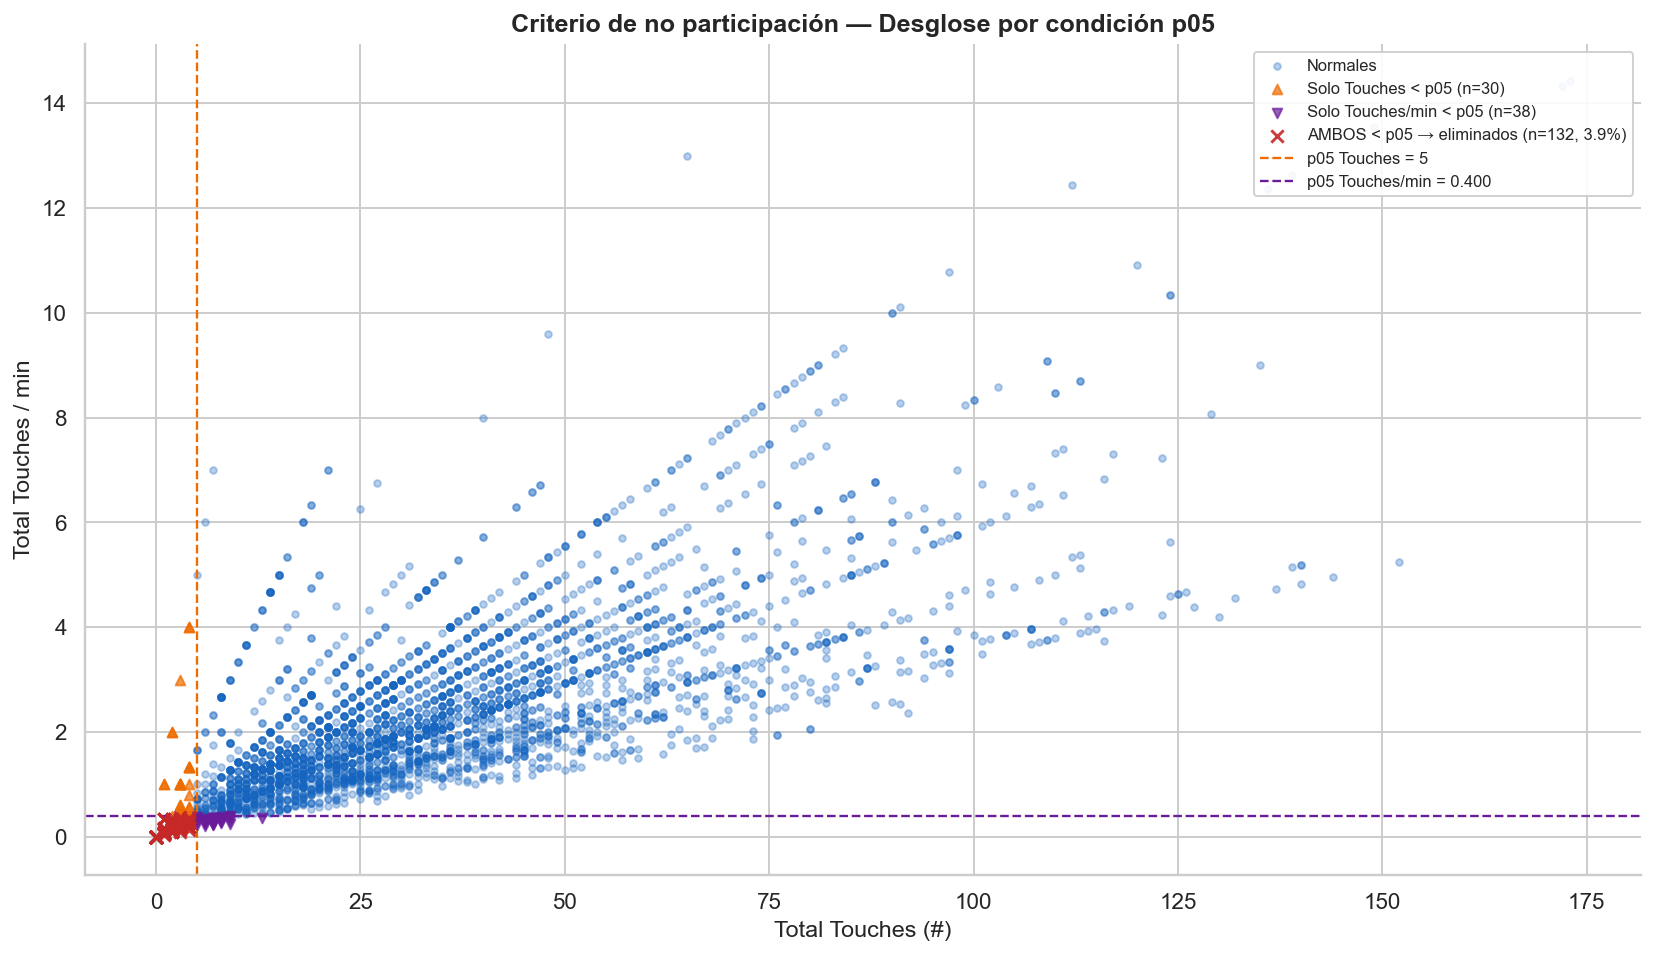


💡 Solo 132 instancias cumplen AMBAS condiciones simultáneamente.
   El criterio AND es 68 instancias más conservador que el OR.


In [53]:
# ── 2.2 Scatter: TotalTouches vs TouchesPerMin — diagnóstico visual ──
mask_low_touches = (df[COL["TotalTouches"]] < q05_touches)
mask_low_tpm     = (df[COL["TouchesPerMin"]] < q05_tpm)
mask_no_part     = mask_low_touches & mask_low_tpm  # conjunción = conservador

# ── Desglose detallado de instancias por debajo de p05 ──
n_only_touches = (mask_low_touches & ~mask_low_tpm).sum()
n_only_tpm     = (mask_low_tpm & ~mask_low_touches).sum()
n_both         = mask_no_part.sum()
n_either       = (mask_low_touches | mask_low_tpm).sum()

print("═" * 60)
print("  DESGLOSE DE INSTANCIAS POR DEBAJO DE p05")
print("═" * 60)
print(f"  Total Touches < p05 (total):       {mask_low_touches.sum():>5}  ({mask_low_touches.sum()/len(df)*100:.2f}%)")
print(f"  Touches/min   < p05 (total):       {mask_low_tpm.sum():>5}  ({mask_low_tpm.sum()/len(df)*100:.2f}%)")
print(f"  ─────────────────────────────────────────────")
print(f"  Solo Touches < p05 (no TPM):       {n_only_touches:>5}  ({n_only_touches/len(df)*100:.2f}%)")
print(f"  Solo Touches/min < p05 (no Abs):   {n_only_tpm:>5}  ({n_only_tpm/len(df)*100:.2f}%)")
print(f"  AMBOS < p05 (criterio aplicado):   {n_both:>5}  ({n_both/len(df)*100:.2f}%) ← se eliminan")
print(f"  Cualquiera < p05 (unión OR):       {n_either:>5}  ({n_either/len(df)*100:.2f}%)")
print("═" * 60)

n_flag   = mask_no_part.sum()
pct_flag = n_flag / len(df) * 100

# ── Gráfico con 4 categorías ──
mask_only_t  = mask_low_touches & ~mask_low_tpm
mask_only_tp = mask_low_tpm & ~mask_low_touches
mask_normal  = ~mask_low_touches & ~mask_low_tpm

fig, ax = plt.subplots(figsize=(12, 7))

ax.scatter(df.loc[mask_normal, COL["TotalTouches"]],
           df.loc[mask_normal, COL["TouchesPerMin"]],
           s=12, alpha=0.30, color=PALETTE["azul"], label="Normales", zorder=2)

ax.scatter(df.loc[mask_only_t, COL["TotalTouches"]],
           df.loc[mask_only_t, COL["TouchesPerMin"]],
           s=25, alpha=0.7, color=PALETTE["naranja"], marker="^",
           label=f"Solo Touches < p05 (n={n_only_touches})", zorder=3)

ax.scatter(df.loc[mask_only_tp, COL["TotalTouches"]],
           df.loc[mask_only_tp, COL["TouchesPerMin"]],
           s=25, alpha=0.7, color=PALETTE["morado"], marker="v",
           label=f"Solo Touches/min < p05 (n={n_only_tpm})", zorder=3)

ax.scatter(df.loc[mask_no_part, COL["TotalTouches"]],
           df.loc[mask_no_part, COL["TouchesPerMin"]],
           s=40, alpha=0.90, color=PALETTE["rojo"], marker="x", linewidths=1.5,
           label=f"AMBOS < p05 → eliminados (n={n_both}, {pct_flag:.1f}%)", zorder=4)

ax.axvline(q05_touches, color=PALETTE["naranja"], ls="--", lw=1.2,
           label=f"p05 Touches = {q05_touches:.0f}")
ax.axhline(q05_tpm, color=PALETTE["morado"], ls="--", lw=1.2,
           label=f"p05 Touches/min = {q05_tpm:.3f}")

ax.set_xlabel("Total Touches (#)", fontsize=12)
ax.set_ylabel("Total Touches / min", fontsize=12)
ax.set_title("Criterio de no participación — Desglose por condición p05", fontsize=13)
ax.legend(fontsize=8.5, loc="upper right", framealpha=0.9)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

print(f"\n💡 Solo {n_both} instancias cumplen AMBAS condiciones simultáneamente.")
print(f"   El criterio AND es {n_either - n_both} instancias más conservador que el OR.")

## 3 · Detección de outliers superiores (sin eliminación)

Se detectan outliers superiores por **IQR** (k = 1.5) y **z-score** (|z| > 3) en las 4 VD absolutas. **No se eliminan**: representan rendimiento extremo pero real. Se reportan para transparencia y para evaluar su impacto en análisis posteriores.

In [54]:
# ── 3.1 Reporte de outliers superiores por IQR y z-score ──
print("═" * 70)
print("  OUTLIERS SUPERIORES — Reporte informativo (NO se eliminan)")
print("═" * 70)

outlier_report = []
for col in VD_ABS:
    mask_iqr, info = detect_outliers_iqr(df[col])
    mask_z, _      = detect_outliers_zscore(df[col])

    # Solo superiores
    n_iqr_upper = (df[col] > info["upper"]).sum()
    n_z_upper   = ((df[col] - df[col].mean()) / df[col].std() > 3).sum()

    outlier_report.append({
        "Variable": col,
        "IQR upper": f"{info['upper']:.1f}",
        "n > IQR upper": n_iqr_upper,
        "% > IQR upper": round(n_iqr_upper / len(df) * 100, 2),
        "n |z| > 3 (sup)": n_z_upper,
        "% |z| > 3 (sup)": round(n_z_upper / len(df) * 100, 2),
    })

df_outliers = pd.DataFrame(outlier_report)
display(df_outliers)

print("\n⚠️  Estos outliers NO se eliminan — representan rendimiento real.")

══════════════════════════════════════════════════════════════════════
  OUTLIERS SUPERIORES — Reporte informativo (NO se eliminan)
══════════════════════════════════════════════════════════════════════


,Variable,IQR upper,n > IQR upper,% > IQR upper,n |z| > 3 (sup),% |z| > 3 (sup)
0,Total Touches (#),92.0,120,3.50,47,1.37
1,Golpeos +15 m/s,7.5,183,5.34,64,1.87
2,Distance Covered (m),3006.4,116,3.39,42,1.23
3,High Intensity Distance (20 km/h),87.5,333,9.72,92,2.69



⚠️  Estos outliers NO se eliminan — representan rendimiento real.


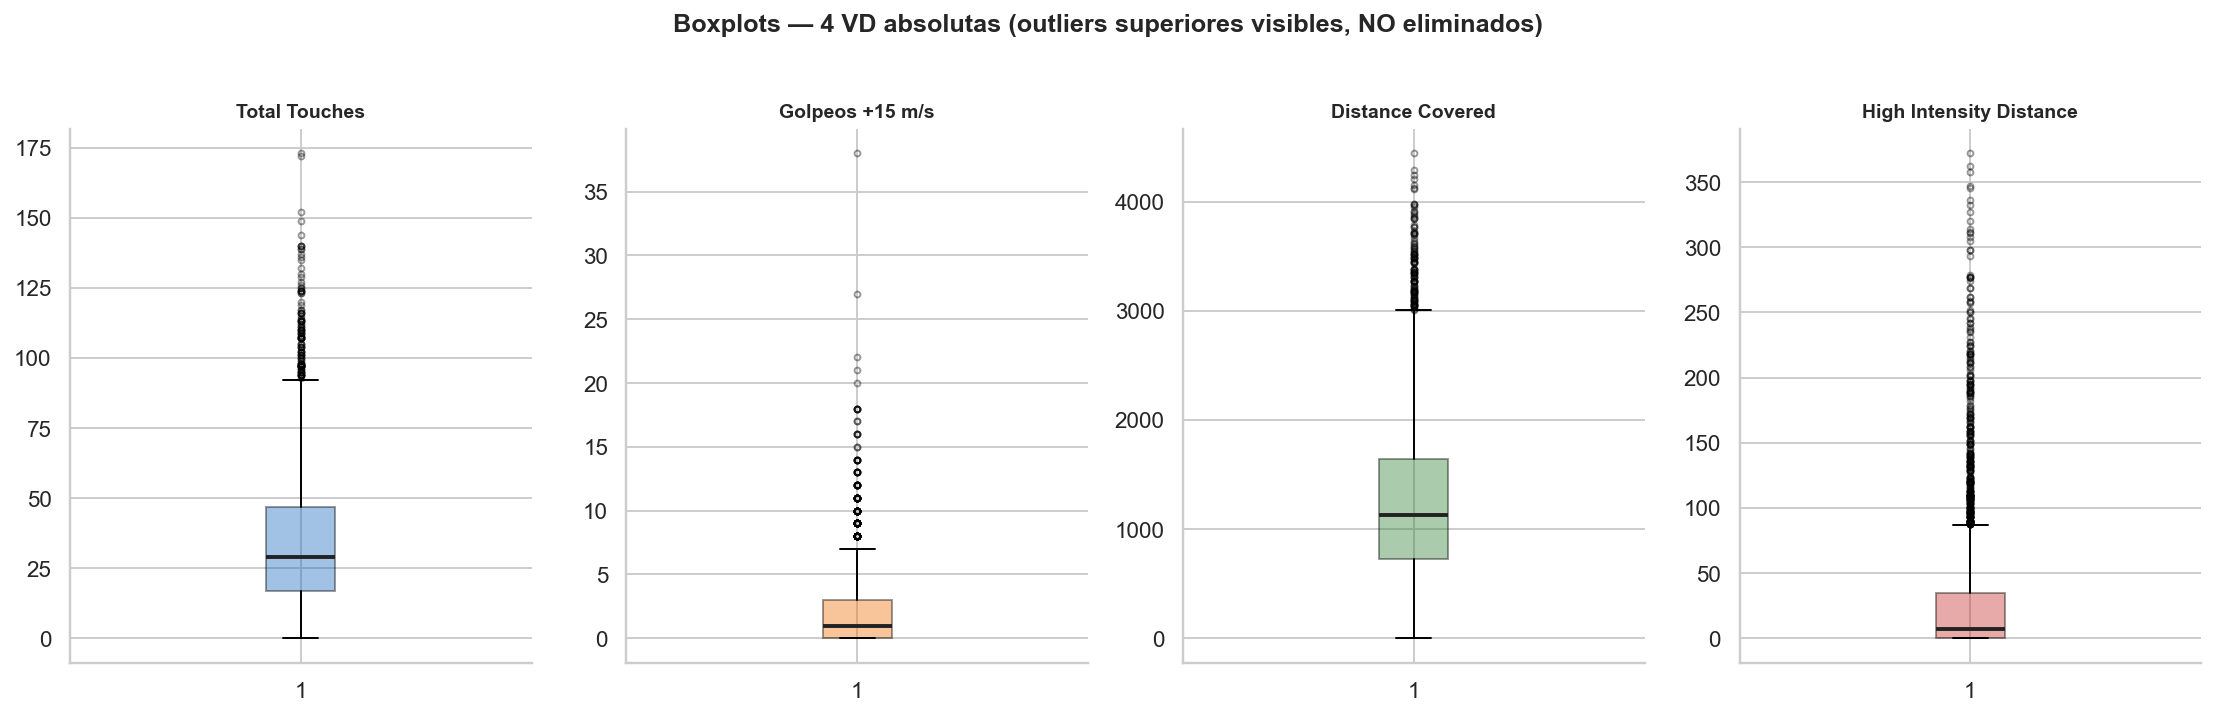

In [55]:
# ── 3.2 Boxplots de las 4 VD absolutas ──
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
colores = [PALETTE["azul"], PALETTE["naranja"], PALETTE["verde"], PALETTE["rojo"]]

for ax, col, color in zip(axes, VD_ABS, colores):
    bp = ax.boxplot(df[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor=color, alpha=0.4),
                    medianprops=dict(color="#222", lw=2),
                    flierprops=dict(marker="o", markersize=3, alpha=0.4))
    ax.set_title(col.split("(")[0].strip() if "(" in col else col.split("[")[0].strip(),
                 fontsize=10, fontweight="bold")
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("Boxplots — 4 VD absolutas (outliers superiores visibles, NO eliminados)",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 4 · Análisis de Golpeos +15 m/s (PassesOver15ms)

Variable con **alta proporción de ceros** por naturaleza (muchas tareas no implican golpeos potentes). Se analiza su distribución pero **no se usa como criterio de exclusión** salvo incoherencia evidente.

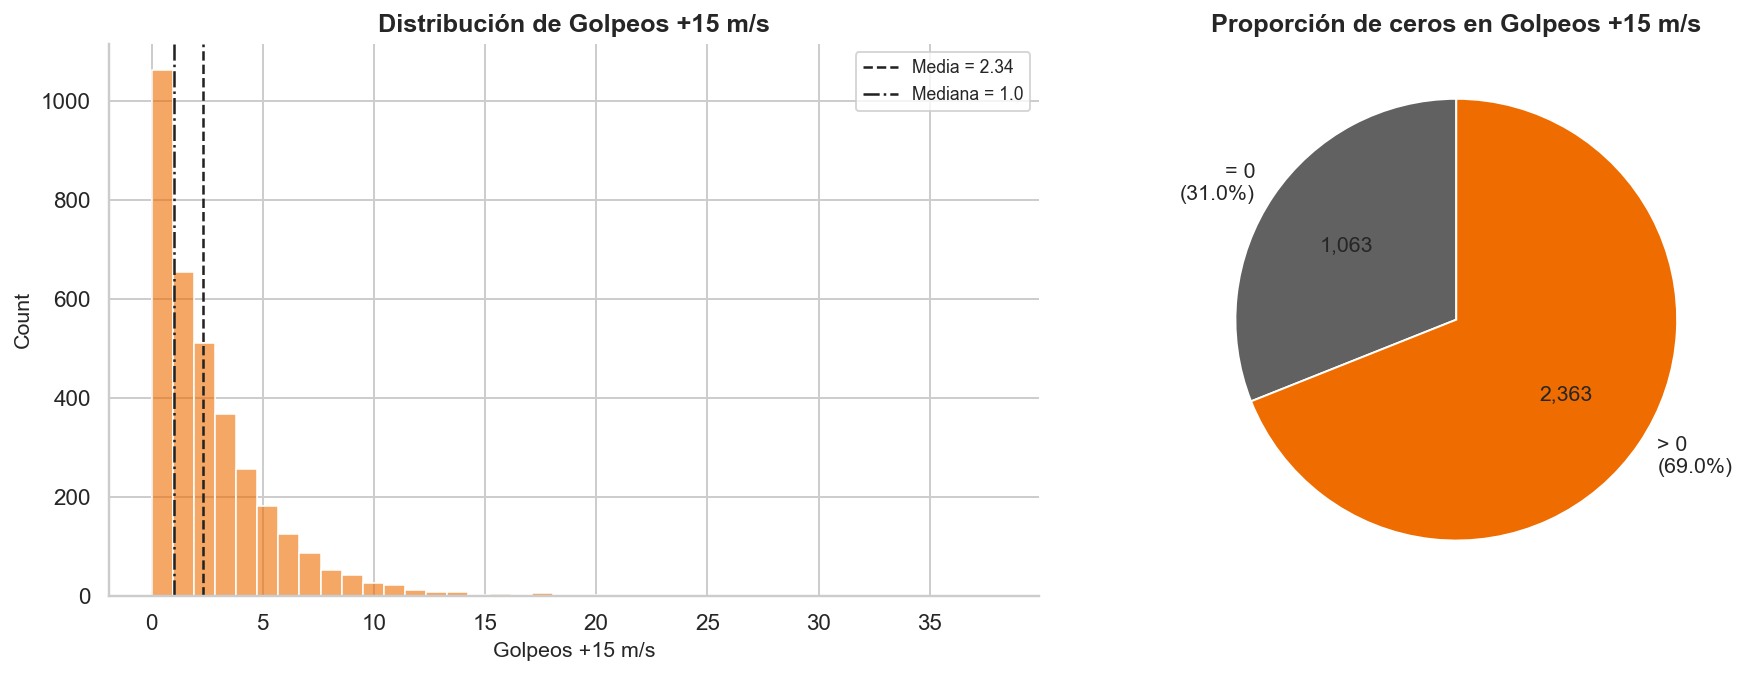


📊 Golpeos +15 m/s = 0: 1,063 / 3,426 (31.0%)
   → Esperado: muchas tareas no implican golpeos potentes.
   → NO se usa como criterio de exclusión.


In [56]:
# ── 4.1 Distribución y % de ceros de Golpeos +15 m/s ──
col_passes = COL["PassesOver15ms"]
n_ceros_passes = (df[col_passes] == 0).sum()
pct_ceros_passes = n_ceros_passes / len(df) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma
sns.histplot(df[col_passes], bins=40, color=PALETTE["naranja"], edgecolor="white",
             alpha=0.6, ax=axes[0])
axes[0].set_title("Distribución de Golpeos +15 m/s", fontweight="bold")
axes[0].set_xlabel("Golpeos +15 m/s")
axes[0].axvline(df[col_passes].mean(), color="#222", ls="--", lw=1.3,
                label=f"Media = {df[col_passes].mean():.2f}")
axes[0].axvline(df[col_passes].median(), color="#222", ls="-.", lw=1.3,
                label=f"Mediana = {df[col_passes].median():.1f}")
axes[0].legend(fontsize=9)
axes[0].spines[["top", "right"]].set_visible(False)

# Proporción ceros vs no-ceros
valores = [n_ceros_passes, len(df) - n_ceros_passes]
etiquetas = [f"= 0\n({pct_ceros_passes:.1f}%)", f"> 0\n({100-pct_ceros_passes:.1f}%)"]
axes[1].pie(valores, labels=etiquetas, colors=[PALETTE["gris"], PALETTE["naranja"]],
            autopct=lambda p: f"{int(p/100*len(df)):,}", startangle=90,
            textprops={"fontsize": 11})
axes[1].set_title("Proporción de ceros en Golpeos +15 m/s", fontweight="bold")

plt.tight_layout()
plt.show()

print(f"\n📊 Golpeos +15 m/s = 0: {n_ceros_passes:,} / {len(df):,} ({pct_ceros_passes:.1f}%)")
print(f"   → Esperado: muchas tareas no implican golpeos potentes.")
print(f"   → NO se usa como criterio de exclusión.")

## 5 · Análisis de High Intensity Distance (20 km/h)

Distancia a alta intensidad (> 5.5 m/s ≈ 20 km/h). Puede tener ceros legítimos (tareas técnicas sin desplazamiento intenso o sprints). Se analiza pero **no se usa como criterio principal de exclusión**.

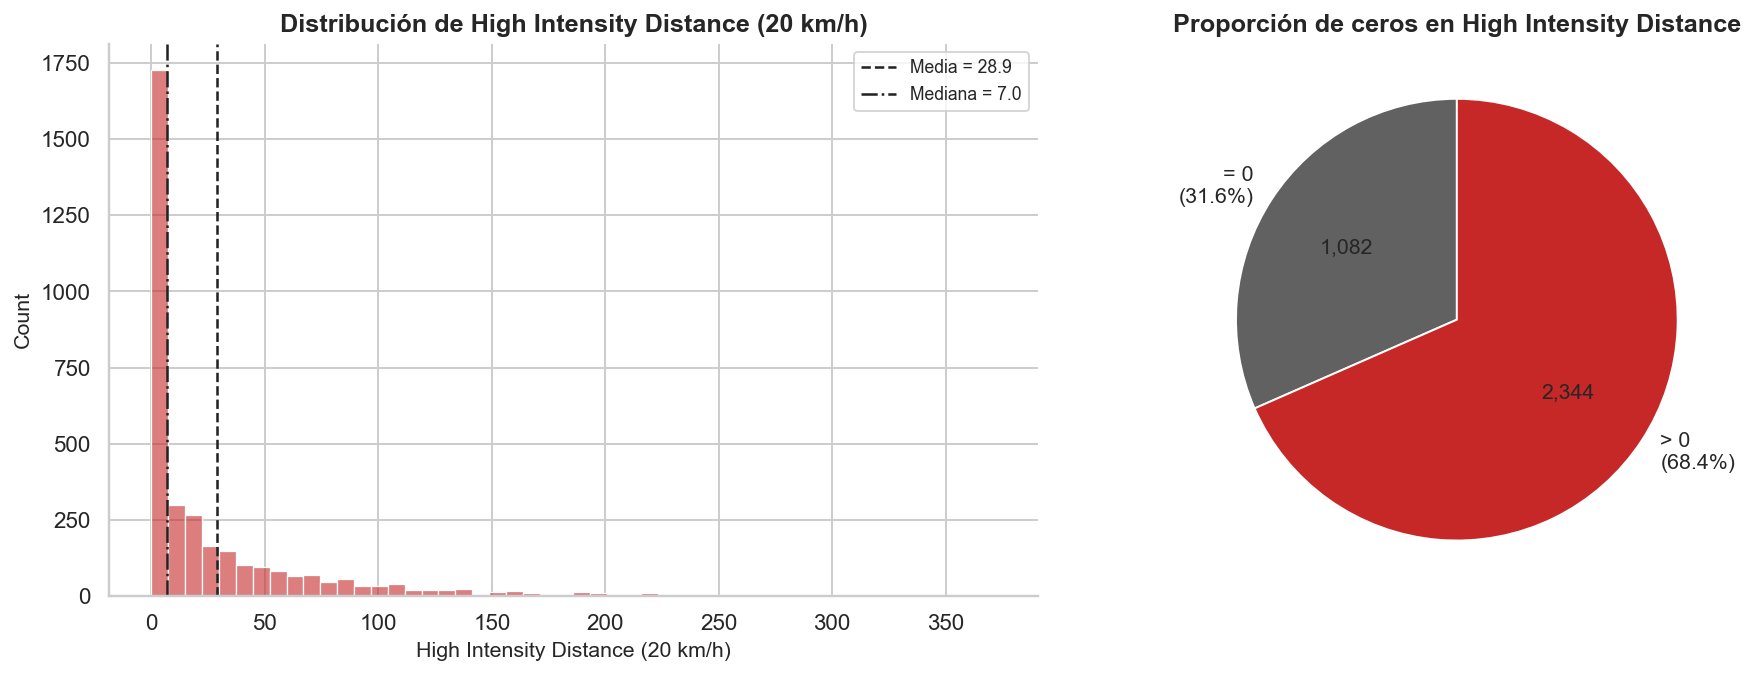


📊 High Intensity Distance (20 km/h) = 0: 1,082 / 3,426 (31.6%)
   → Esperado: no todas las tareas implican sprints (> 5.5 m/s ≈ 20 km/h).
   → NO se usa como criterio de exclusión.


In [57]:
# ── 5.1 Distribución y % de ceros de High Intensity Distance (20 km/h) ──
col_hid = COL["HIDCovered"]
n_ceros_hid = (df[col_hid] == 0).sum()
pct_ceros_hid = n_ceros_hid / len(df) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df[col_hid], bins=50, color=PALETTE["rojo"], edgecolor="white",
             alpha=0.6, ax=axes[0])
axes[0].set_title("Distribución de High Intensity Distance (20 km/h)", fontweight="bold")
axes[0].set_xlabel("High Intensity Distance (20 km/h)")
axes[0].axvline(df[col_hid].mean(), color="#222", ls="--", lw=1.3,
                label=f"Media = {df[col_hid].mean():.1f}")
axes[0].axvline(df[col_hid].median(), color="#222", ls="-.", lw=1.3,
                label=f"Mediana = {df[col_hid].median():.1f}")
axes[0].legend(fontsize=9)
axes[0].spines[["top", "right"]].set_visible(False)

valores = [n_ceros_hid, len(df) - n_ceros_hid]
etiquetas = [f"= 0\n({pct_ceros_hid:.1f}%)", f"> 0\n({100-pct_ceros_hid:.1f}%)"]
axes[1].pie(valores, labels=etiquetas, colors=[PALETTE["gris"], PALETTE["rojo"]],
            autopct=lambda p: f"{int(p/100*len(df)):,}", startangle=90,
            textprops={"fontsize": 11})
axes[1].set_title("Proporción de ceros en High Intensity Distance", fontweight="bold")

plt.tight_layout()
plt.show()

print(f"\n📊 High Intensity Distance (20 km/h) = 0: {n_ceros_hid:,} / {len(df):,} ({pct_ceros_hid:.1f}%)")
print(f"   → Esperado: no todas las tareas implican sprints (> 5.5 m/s ≈ 20 km/h).")
print(f"   → NO se usa como criterio de exclusión.")

## 6 · Distance Covered — Distribución y relación con las instancias excluidas

Se analiza la distribución de **Distance Covered**, se identifican instancias con valor 0 y se estudia cómo se comportan las instancias ya excluidas por el criterio de toques en las variables de distancia (absoluta y normalizada por minuto).

════════════════════════════════════════════════════════════
  PERCENTILES — Distance Covered (m)
════════════════════════════════════════════════════════════
0.01      22.50
0.05     277.25
0.10     437.50
0.25     727.00
0.50    1128.00
Name: valor, dtype: float64

🔑 Valores clave:
   Instancias con Distance = 0:  1 (0.03%)
   p05 = 277.2 m
   p10 = 437.5 m


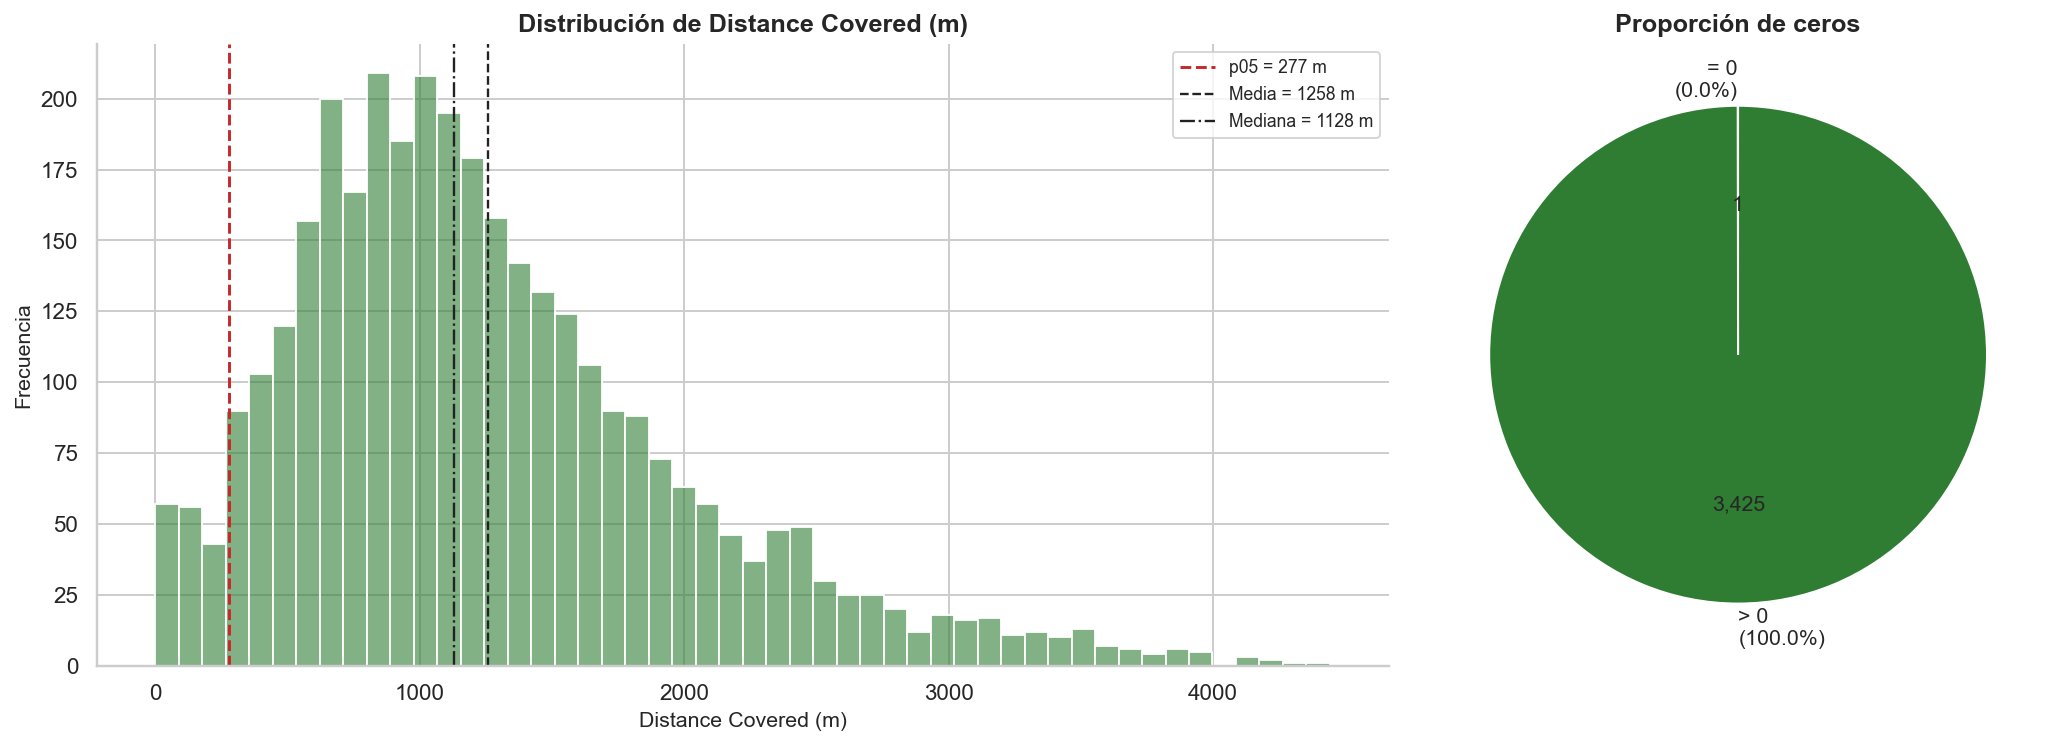

In [58]:
# ── 6.1 Distribución de Distance Covered: histograma, ceros, percentiles ──
col_dist    = COL["DistanceCovered"]
col_distmin = COL["DistPerMin"]

n_ceros_dist = (df[col_dist] == 0).sum()
pct_ceros_dist = n_ceros_dist / len(df) * 100
q05_dist = df[col_dist].quantile(0.05)
q10_dist = df[col_dist].quantile(0.10)

print("═" * 60)
print("  PERCENTILES — Distance Covered (m)")
print("═" * 60)
print(compute_percentiles(df[col_dist]))

print(f"\n🔑 Valores clave:")
print(f"   Instancias con Distance = 0:  {n_ceros_dist} ({pct_ceros_dist:.2f}%)")
print(f"   p05 = {q05_dist:.1f} m")
print(f"   p10 = {q10_dist:.1f} m")

# ── Histograma con p05 y media ──
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5),
                         gridspec_kw={"width_ratios": [2, 1]})

ax = axes[0]
sns.histplot(df[col_dist], bins=50, color=PALETTE["verde"],
             edgecolor="white", alpha=0.6, ax=ax)
ax.axvline(q05_dist, color=PALETTE["rojo"], ls="--", lw=1.5,
           label=f"p05 = {q05_dist:.0f} m")
ax.axvline(df[col_dist].mean(), color="#222", ls="--", lw=1.2,
           label=f"Media = {df[col_dist].mean():.0f} m")
ax.axvline(df[col_dist].median(), color="#222", ls="-.", lw=1.2,
           label=f"Mediana = {df[col_dist].median():.0f} m")
ax.set_title("Distribución de Distance Covered (m)", fontweight="bold")
ax.set_xlabel("Distance Covered (m)")
ax.set_ylabel("Frecuencia")
ax.legend(fontsize=9)
ax.spines[["top", "right"]].set_visible(False)

# Pie chart: ceros vs no ceros
ax2 = axes[1]
if n_ceros_dist > 0:
    vals = [n_ceros_dist, len(df) - n_ceros_dist]
    lbls = [f"= 0\n({pct_ceros_dist:.1f}%)", f"> 0\n({100-pct_ceros_dist:.1f}%)"]
    ax2.pie(vals, labels=lbls, colors=[PALETTE["gris"], PALETTE["verde"]],
            autopct=lambda p: f"{int(p/100*len(df)):,}", startangle=90,
            textprops={"fontsize": 11})
    ax2.set_title("Proporción de ceros", fontweight="bold")
else:
    ax2.text(0.5, 0.5, f"No hay instancias\ncon Distance = 0",
             ha="center", va="center", fontsize=13, fontweight="bold",
             transform=ax2.transAxes)
    ax2.set_title("Proporción de ceros", fontweight="bold")
    ax2.axis("off")

plt.tight_layout()
plt.show()

In [59]:
# ── 6.1b Comprobación: ¿las instancias con Distance Covered = 0 fueron excluidas por toques? ──

mask_dist_cero = df[col_dist] == 0
n_dist_cero = mask_dist_cero.sum()

# ¿Cuántas de esas también cumplen el criterio de eliminación por toques?
n_dist_cero_y_elim = (mask_dist_cero & mask_no_part).sum()
n_dist_cero_no_elim = (mask_dist_cero & ~mask_no_part).sum()

print("═" * 65)
print("  COMPROBACIÓN: Instancias con Distance Covered = 0")
print("═" * 65)
print(f"\n  Total instancias con Distance = 0:  {n_dist_cero}")
print(f"  ─────────────────────────────────────────────")
print(f"  Eliminadas por criterio de toques:   {n_dist_cero_y_elim}  ({'✅ TODAS' if n_dist_cero_no_elim == 0 else f'⚠️ Quedan {n_dist_cero_no_elim} sin eliminar'})")
print(f"  NO eliminadas (permanecen):          {n_dist_cero_no_elim}")

if n_dist_cero_no_elim > 0:
    print(f"\n  ⚠️ Detalle de las {n_dist_cero_no_elim} instancias con Distance=0 NO eliminadas:")
    cols_mostrar = ["Player Name", COL["TotalTouches"], COL["TouchesPerMin"],
                    col_dist, col_distmin]
    cols_disponibles = [c for c in cols_mostrar if c in df.columns]
    display(df.loc[mask_dist_cero & ~mask_no_part, cols_disponibles])
else:
    print(f"\n  ✅ Todas las instancias con Distance Covered = 0 han sido")
    print(f"     excluidas por el criterio de toques (p05 conjunto).")
    print(f"     No es necesario un filtro adicional por distancia.")
print("═" * 65)

═════════════════════════════════════════════════════════════════
  COMPROBACIÓN: Instancias con Distance Covered = 0
═════════════════════════════════════════════════════════════════

  Total instancias con Distance = 0:  1
  ─────────────────────────────────────────────
  Eliminadas por criterio de toques:   1  (✅ TODAS)
  NO eliminadas (permanecen):          0

  ✅ Todas las instancias con Distance Covered = 0 han sido
     excluidas por el criterio de toques (p05 conjunto).
     No es necesario un filtro adicional por distancia.
═════════════════════════════════════════════════════════════════


In [60]:
# ── 6.2 Relación: instancias excluidas por toques vs Distance Covered ──

# Perfil de Distance en eliminados vs conservados
dist_elim = df.loc[mask_no_part, col_dist]
dist_rest = df.loc[~mask_no_part, col_dist]
distmin_elim = df.loc[mask_no_part, col_distmin]
distmin_rest = df.loc[~mask_no_part, col_distmin]

# ¿Cuántos eliminados están también bajo p05 de distancia?
mask_dist_low = df[col_dist] < q05_dist
n_elim_bajo_p05_dist = (mask_no_part & mask_dist_low).sum()

q05_distmin = df[col_distmin].quantile(0.05)
mask_distmin_low = df[col_distmin] < q05_distmin
n_elim_bajo_p05_distmin = (mask_no_part & mask_distmin_low).sum()

print("═" * 65)
print("  RELACIÓN: Eliminados por toques vs Distance Covered")
print("═" * 65)
print(f"\n  Instancias eliminadas (criterio toques): {mask_no_part.sum()}")
print(f"\n  Distance Covered (m):")
print(f"    Media eliminados:    {dist_elim.mean():>8.1f} m")
print(f"    Media conservados:   {dist_rest.mean():>8.1f} m")
print(f"    Ratio elim/cons:     {dist_elim.mean()/dist_rest.mean():>8.3f}")
print(f"    Eliminados bajo p05 dist ({q05_dist:.0f} m): {n_elim_bajo_p05_dist}/{mask_no_part.sum()} ({n_elim_bajo_p05_dist/mask_no_part.sum()*100:.1f}%)")
print(f"\n  Distance Covered / min:")
print(f"    p05 Dist/min:        {q05_distmin:.2f} m/min")
print(f"    Media eliminados:    {distmin_elim.mean():>8.2f} m/min")
print(f"    Media conservados:   {distmin_rest.mean():>8.2f} m/min")
print(f"    Ratio elim/cons:     {distmin_elim.mean()/distmin_rest.mean():>8.3f}")
print(f"    Eliminados bajo p05 dist/min:  {n_elim_bajo_p05_distmin}/{mask_no_part.sum()} ({n_elim_bajo_p05_distmin/mask_no_part.sum()*100:.1f}%)")
print("═" * 65)

═════════════════════════════════════════════════════════════════
  RELACIÓN: Eliminados por toques vs Distance Covered
═════════════════════════════════════════════════════════════════

  Instancias eliminadas (criterio toques): 132

  Distance Covered (m):
    Media eliminados:       403.0 m
    Media conservados:     1292.7 m
    Ratio elim/cons:        0.312
    Eliminados bajo p05 dist (277 m): 86/132 (65.2%)

  Distance Covered / min:
    p05 Dist/min:        29.17 m/min
    Media eliminados:       30.51 m/min
    Media conservados:      81.22 m/min
    Ratio elim/cons:        0.376
    Eliminados bajo p05 dist/min:  83/132 (62.9%)
═════════════════════════════════════════════════════════════════


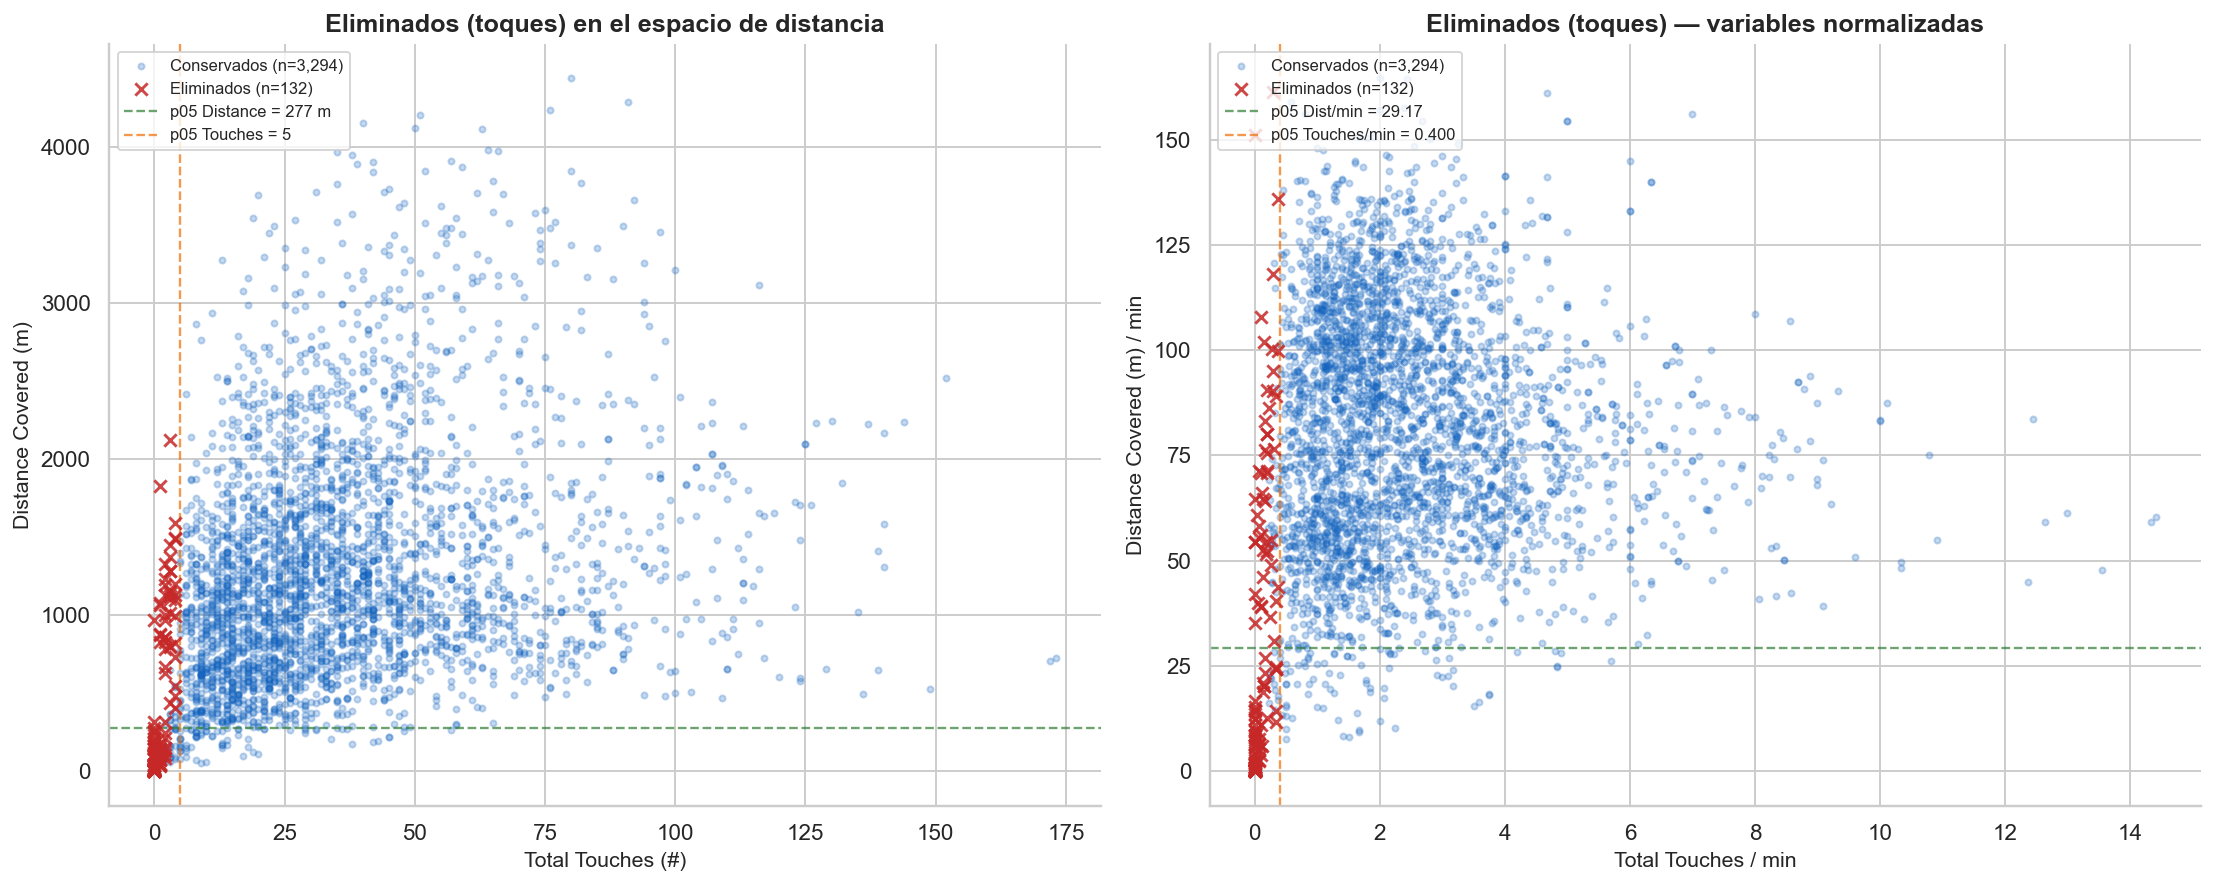


💡 La mayoría de instancias eliminadas por toques se concentran
   en la zona baja de distancia, confirmando coherencia del criterio.


In [61]:
# ── 6.3 Visualización: eliminados por toques en el espacio de distancia ──

fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))

# --- Panel 1: Distance Covered (m) vs Total Touches ---
ax = axes[0]
ax.scatter(df.loc[~mask_no_part, COL["TotalTouches"]],
           df.loc[~mask_no_part, col_dist],
           s=10, alpha=0.25, color=PALETTE["azul"],
           label=f"Conservados (n={( ~mask_no_part).sum():,})", zorder=2)
ax.scatter(df.loc[mask_no_part, COL["TotalTouches"]],
           df.loc[mask_no_part, col_dist],
           s=40, alpha=0.85, color=PALETTE["rojo"], marker="x", linewidths=1.5,
           label=f"Eliminados (n={mask_no_part.sum()})", zorder=3)
ax.axhline(q05_dist, color=PALETTE["verde"], ls="--", lw=1.2, alpha=0.7,
           label=f"p05 Distance = {q05_dist:.0f} m")
ax.axvline(q05_touches, color=PALETTE["naranja"], ls="--", lw=1.2, alpha=0.7,
           label=f"p05 Touches = {q05_touches:.0f}")
ax.set_xlabel("Total Touches (#)", fontsize=11)
ax.set_ylabel("Distance Covered (m)", fontsize=11)
ax.set_title("Eliminados (toques) en el espacio de distancia", fontweight="bold")
ax.legend(fontsize=8.5, loc="upper left")
ax.spines[["top", "right"]].set_visible(False)

# --- Panel 2: Distance Covered/min vs Touches/min ---
ax2 = axes[1]
ax2.scatter(df.loc[~mask_no_part, COL["TouchesPerMin"]],
            df.loc[~mask_no_part, col_distmin],
            s=10, alpha=0.25, color=PALETTE["azul"],
            label=f"Conservados (n={( ~mask_no_part).sum():,})", zorder=2)
ax2.scatter(df.loc[mask_no_part, COL["TouchesPerMin"]],
            df.loc[mask_no_part, col_distmin],
            s=40, alpha=0.85, color=PALETTE["rojo"], marker="x", linewidths=1.5,
            label=f"Eliminados (n={mask_no_part.sum()})", zorder=3)
ax2.axhline(q05_distmin, color=PALETTE["verde"], ls="--", lw=1.2, alpha=0.7,
            label=f"p05 Dist/min = {q05_distmin:.2f}")
ax2.axvline(q05_tpm, color=PALETTE["naranja"], ls="--", lw=1.2, alpha=0.7,
            label=f"p05 Touches/min = {q05_tpm:.3f}")
ax2.set_xlabel("Total Touches / min", fontsize=11)
ax2.set_ylabel("Distance Covered (m) / min", fontsize=11)
ax2.set_title("Eliminados (toques) — variables normalizadas", fontweight="bold")
ax2.legend(fontsize=8.5, loc="upper left")
ax2.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

print(f"\n💡 La mayoría de instancias eliminadas por toques se concentran")
print(f"   en la zona baja de distancia, confirmando coherencia del criterio.")

## 7 · Aplicación del filtro y análisis detallado del impacto

Se aplica el criterio de **p05 conjunto en toques** (Escenario A) por ser:

1. **Conservador**: exige que ambas condiciones se cumplan simultáneamente (AND).
2. **Interpretable**: un jugador sin toques ni tasa de toques no participó activamente.
3. **Independiente de la dimensión física**: no penaliza tareas técnicas sin desplazamiento.
4. **Coherente con distancia**: la sección anterior confirma que los eliminados también concentran valores bajos de distancia.

In [62]:
# ── 7.1 Aplicación del Escenario A ──
mask_A = mask_no_part   # alias para claridad en secciones posteriores
df_antes = df.copy()
df_clean = df[~mask_A].reset_index(drop=True)

n_elim = len(df_antes) - len(df_clean)
pct_elim = n_elim / len(df_antes) * 100

print("═" * 60)
print("  APLICACIÓN DEL FILTRO — Escenario A (toques p05 conjunto)")
print("═" * 60)
print(f"  Instancias antes:     {len(df_antes):,}")
print(f"  Instancias eliminadas:{n_elim:>6}  ({pct_elim:.2f}%)")
print(f"  Instancias después:   {len(df_clean):,}")
print("═" * 60)

════════════════════════════════════════════════════════════
  APLICACIÓN DEL FILTRO — Escenario A (toques p05 conjunto)
════════════════════════════════════════════════════════════
  Instancias antes:     3,426
  Instancias eliminadas:   132  (3.85%)
  Instancias después:   3,294
════════════════════════════════════════════════════════════


In [63]:
# ── 7.2 Tabla antes / después ──
comparacion = summarize_before_after(df_antes, df_clean, VD_ALL)
display(comparacion)

N    Media      SD  CV (%)
Variable                                Fase                                  
Total Touches (#)                       Antes    3426    35.05   25.07   71.53
                                        Después  3294    36.41   24.61   67.59
Golpeos +15 m/s                         Antes    3426     2.34    2.85  121.85
                                        Después  3294     2.42    2.87  118.20
Distance Covered (m)                    Antes    3426  1258.44  748.27   59.46
                                        Después  3294  1292.72  736.04   56.94
High Intensity Distance (20 km/h)       Antes    3426    28.90   49.61  171.69
                                        Después  3294    29.56   50.14  169.60
Total Touches / min                     Antes    3426     2.38    1.70   71.66
                                        Después  3294     2.47    1.67   67.78
Golpeos +15 m/s / min                   Antes    3426     0.15    0.18  124.25
                                        Después  3294     0.15    0.19  120.60
Distance Covered (m) / min              Antes    3426    79.26   30.14   38.02
                                        Después  3294    81.22   28.15   34.66
High Intensity Distance (20 km/h) / min Antes    3426     1.64    2.48  151.49
                                        Después  3294     1.67    2.50  149.37

In [64]:
# ── 7.3 Detalle: perfil de los eliminados en cada variable ──

# Tabla resumen: media, mediana, min, max de eliminados vs conservados
perfil_filas = []
for col in VD_ALL:
    s_elim = df_antes.loc[mask_A, col]
    s_cons = df_clean[col]
    perfil_filas.append({
        "Variable": col,
        "Media (elim)": round(s_elim.mean(), 2),
        "Mediana (elim)": round(s_elim.median(), 2),
        "Max (elim)": round(s_elim.max(), 2),
        "Media (cons)": round(s_cons.mean(), 2),
        "Mediana (cons)": round(s_cons.median(), 2),
        "Ratio medias": round(s_elim.mean() / s_cons.mean(), 4) if s_cons.mean() != 0 else 0,
    })

df_perfil = pd.DataFrame(perfil_filas)
display(df_perfil)

print("\n💡 Ratios << 1 confirman que los eliminados tienen valores residuales en todas las VD.")

,Variable,Media (elim),Mediana (elim),Max (elim),Media (cons),Mediana (cons),Ratio medias
0,Total Touches (#),1.11,0.50,4.00,36.41,31.00,0.0306
1,Golpeos +15 m/s,0.11,0.00,2.00,2.42,2.00,0.0469
2,Distance Covered (m),402.99,140.50,2123.00,1292.72,1144.00,0.3117
3,High Intensity Distance (20 km/h),12.23,0.00,186.00,29.56,8.00,0.4136
4,Total Touches / min,0.09,0.02,0.38,2.47,2.06,0.0367
5,Golpeos +15 m/s / min,0.01,0.00,0.14,0.15,0.11,0.0501
6,Distance Covered (m) / min,30.51,12.38,161.29,81.22,81.06,0.3756
7,High Intensity Distance (20 km/h) / min,0.82,0.00,10.86,1.67,0.55,0.4917



💡 Ratios << 1 confirman que los eliminados tienen valores residuales en todas las VD.


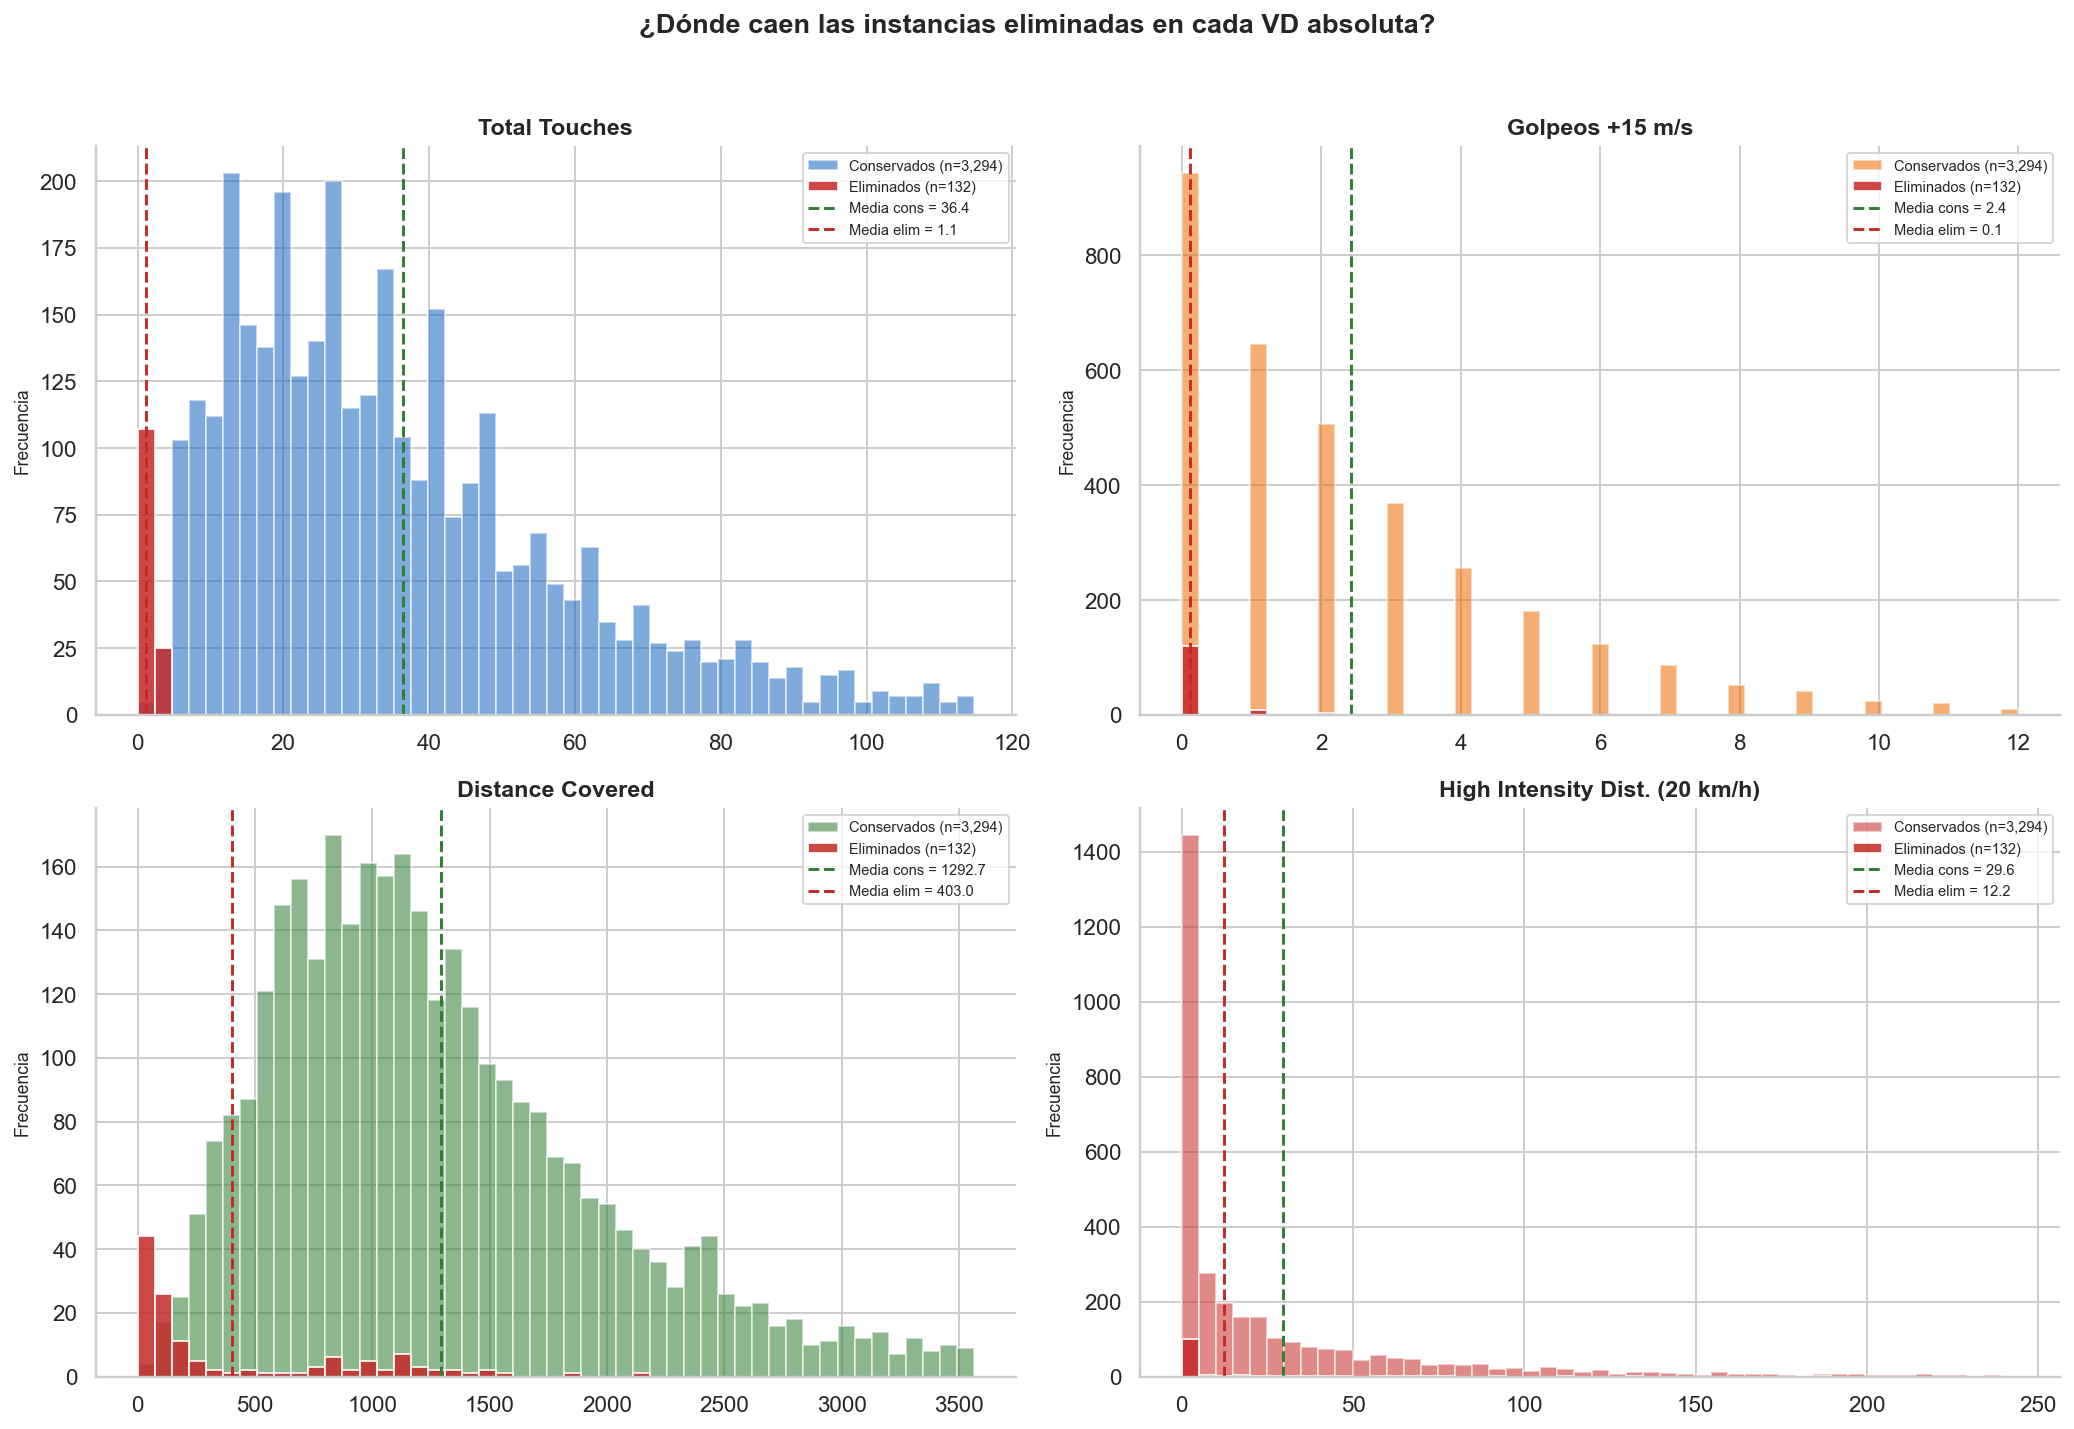

In [65]:
# ── 7.4 Histogramas: distribución total con eliminados resaltados (4 VD absolutas) ──

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()
colores = [PALETTE["azul"], PALETTE["naranja"], PALETTE["verde"], PALETTE["rojo"]]
nombres_cortos = ["Total Touches", "Golpeos +15 m/s", "Distance Covered", "High Intensity Dist. (20 km/h)"]

for i, (col, color, nombre) in enumerate(zip(VD_ABS, colores, nombres_cortos)):
    ax = axes[i]
    s_cons = df_clean[col]
    s_elim = df_antes.loc[mask_A, col]

    # Calcular bins comunes
    all_vals = df_antes[col]
    bins = np.linspace(all_vals.min(), all_vals.quantile(0.99), 50)

    # Histograma conservados
    ax.hist(s_cons, bins=bins, alpha=0.55, color=color,
            edgecolor="white", label=f"Conservados (n={len(s_cons):,})")
    # Histograma eliminados — apilado encima
    ax.hist(s_elim, bins=bins, alpha=0.85, color=PALETTE["rojo"],
            edgecolor="white", label=f"Eliminados (n={len(s_elim)})")

    # Líneas de referencia — colores fijos para distinguir
    ax.axvline(s_cons.mean(), color=PALETTE["verde"], ls="--", lw=1.5,
               label=f"Media cons = {s_cons.mean():.1f}")
    ax.axvline(s_elim.mean(), color=PALETTE["rojo"], ls="--", lw=1.5,
               label=f"Media elim = {s_elim.mean():.1f}")

    ax.set_title(nombre, fontsize=12, fontweight="bold")
    ax.set_ylabel("Frecuencia", fontsize=9)
    ax.legend(fontsize=7.5, loc="upper right")
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("¿Dónde caen las instancias eliminadas en cada VD absoluta?",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

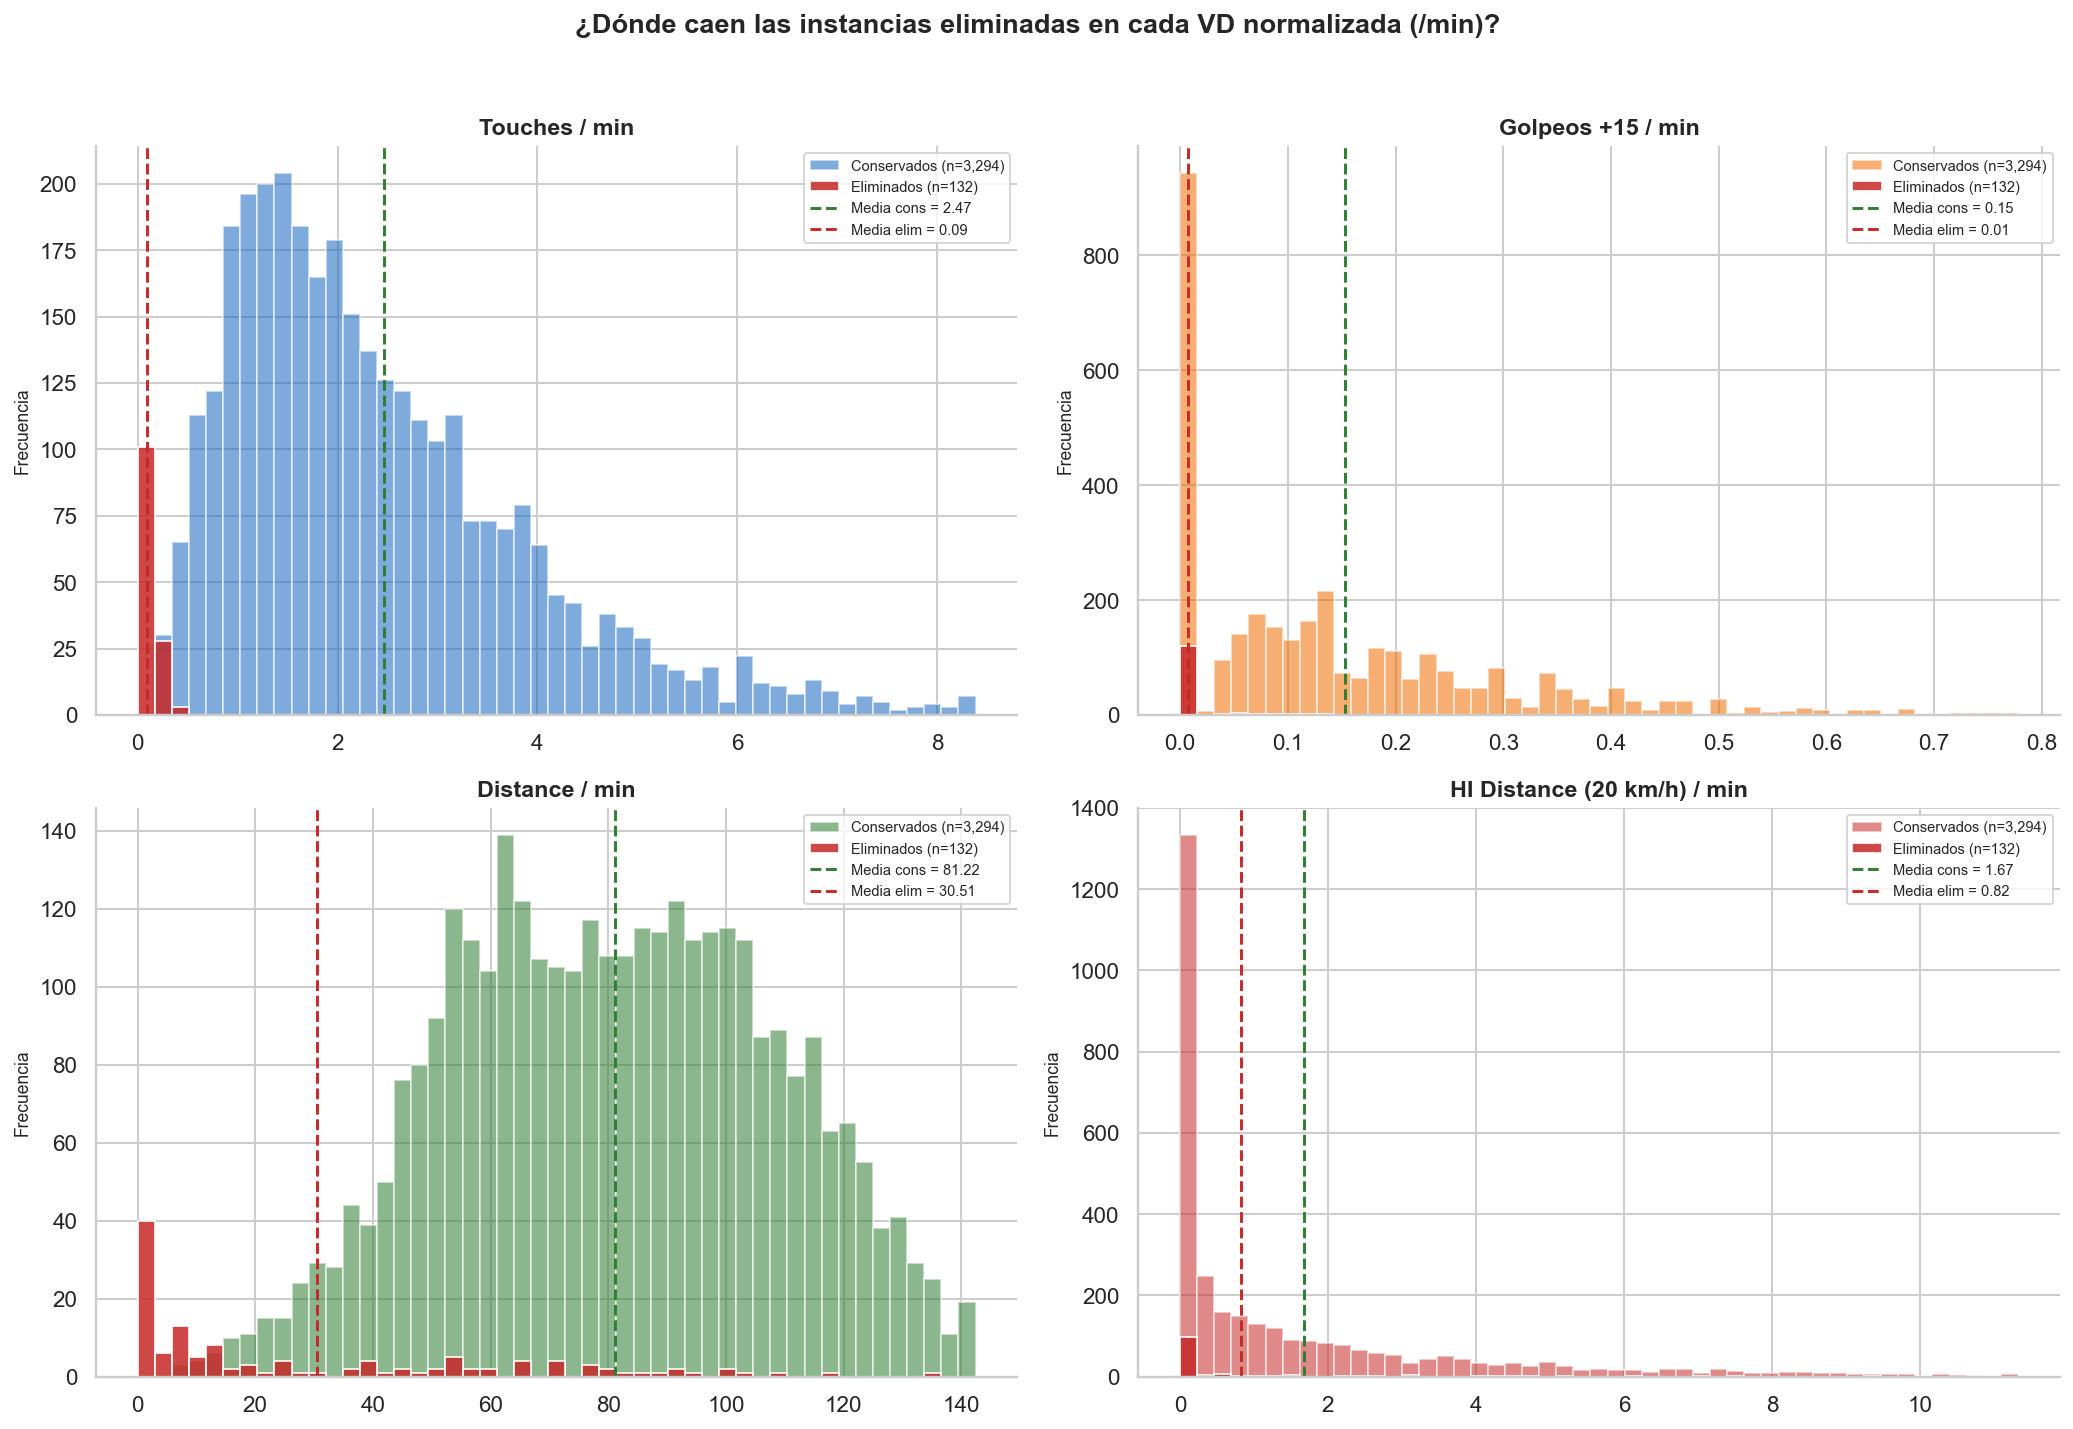

In [66]:
# ── 7.5 Histogramas: distribución total con eliminados resaltados (4 VD normalizadas) ──

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()
colores = [PALETTE["azul"], PALETTE["naranja"], PALETTE["verde"], PALETTE["rojo"]]
nombres_min = ["Touches / min", "Golpeos +15 / min", "Distance / min", "HI Distance (20 km/h) / min"]

for i, (col, color, nombre) in enumerate(zip(VD_MIN, colores, nombres_min)):
    ax = axes[i]
    s_cons = df_clean[col]
    s_elim = df_antes.loc[mask_A, col]

    all_vals = df_antes[col]
    bins = np.linspace(all_vals.min(), all_vals.quantile(0.99), 50)

    ax.hist(s_cons, bins=bins, alpha=0.55, color=color,
            edgecolor="white", label=f"Conservados (n={len(s_cons):,})")
    ax.hist(s_elim, bins=bins, alpha=0.85, color=PALETTE["rojo"],
            edgecolor="white", label=f"Eliminados (n={len(s_elim)})")

    ax.axvline(s_cons.mean(), color=PALETTE["verde"], ls="--", lw=1.5,
               label=f"Media cons = {s_cons.mean():.2f}")
    ax.axvline(s_elim.mean(), color=PALETTE["rojo"], ls="--", lw=1.5,
               label=f"Media elim = {s_elim.mean():.2f}")

    ax.set_title(nombre, fontsize=12, fontweight="bold")
    ax.set_ylabel("Frecuencia", fontsize=9)
    ax.legend(fontsize=7.5, loc="upper right")
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("¿Dónde caen las instancias eliminadas en cada VD normalizada (/min)?",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 8 · Criterio complementario — Exclusión de tareas con duración < 6 min

El análisis exploratorio de las relaciones entre duración de tarea y métricas de rendimiento reveló que las **tareas con Phase Duration < 6 min** presentan anomalías sistemáticas que comprometen la validez de los datos.

### Argumentos para la exclusión

1. **Representatividad del constructo**: tareas de 1-5 min no alcanzan la duración mínima para que la tarea sea realmente representativa. Los indicadores técnicos y físicos no reflejan la dinámica real de un SSG/LSG, únicamente de ciclos y subfases del juego demasiado cortas como para que sean reales. No son lo suficientemente relevantes como para condicionar el estudio posterior a través del GLMM, en el cual podrían aparecer sesgos provenientes de estas instancias.

2. **Artefacto estadístico por normalización /min**: al normalizar por minuto, denominadores pequeños (1-5 min) amplifican el ruido de medición. Por ejemplo, **Touches/min** muestra ratios de hasta **1.56×** y **HID/min** de hasta **3.79×** respecto al resto del dataset. Estas métricas infladas distorsionarían las estimaciones de los GLMM.

3. **Integridad del diseño factorial 2³**: **todas** las instancias con duración < 6 min pertenecen exclusivamente al grupo SSG y a solo 3 de los 12 equipos del estudio (8 de 191 Phase Ids). Su inclusión sesgaría diferencialmente las estimaciones del efecto del formato de juego.

**Criterio**: excluir instancias con `Phase Duration (min) < 6`.

In [67]:
# ── 8.1 Diagnóstico — Perfil de tareas con duración < 6 min ──

col_dur = "Phase Duration (min)"

# Identificar tareas cortas
duraciones_cortas = sorted(df_clean.loc[df_clean[col_dur] < 6, col_dur].unique())
ref = df_clean[df_clean[col_dur] >= 6]

# Tabla resumen por duración
resumen_rows = []
for dur in duraciones_cortas:
    sub = df_clean[df_clean[col_dur] == dur]
    resumen_rows.append({
        "Duración": f"{int(dur)} min",
        "N": len(sub),
        "% total": round(len(sub) / len(df_clean) * 100, 2),
        "Phase Ids": sub["Phase Id"].nunique(),
        "Jugadores": f"{sub['NombreCorrecto'].nunique()} / {df_clean['NombreCorrecto'].nunique()}",
        "Formato": ", ".join(sub["Formato_del_Juego"].unique()),
        "Touches/min": round(sub[COL["TouchesPerMin"]].mean(), 2),
        "Dist/min": round(sub[COL["DistPerMin"]].mean(), 1),
        "Golpeos/min": round(sub[COL["Passes15PerMin"]].mean(), 2),
        "HID/min": round(sub[COL["HIDPerMin"]].mean(), 2),
    })

# Fila de referencia (≥ 6 min)
resumen_rows.append({
    "Duración": "≥ 6 min (ref)",
    "N": len(ref),
    "% total": round(len(ref) / len(df_clean) * 100, 2),
    "Phase Ids": ref["Phase Id"].nunique(),
    "Jugadores": f"{ref['NombreCorrecto'].nunique()} / {df_clean['NombreCorrecto'].nunique()}",
    "Formato": "SSG, LSG",
    "Touches/min": round(ref[COL["TouchesPerMin"]].mean(), 2),
    "Dist/min": round(ref[COL["DistPerMin"]].mean(), 1),
    "Golpeos/min": round(ref[COL["Passes15PerMin"]].mean(), 2),
    "HID/min": round(ref[COL["HIDPerMin"]].mean(), 2),
})

df_resumen_dur = pd.DataFrame(resumen_rows)

print("═" * 75)
print("  DIAGNÓSTICO — Tareas con Phase Duration < 6 min")
print("═" * 75)
display(df_resumen_dur)

# Totales
mask_short = df_clean[col_dur] < 6
n_short = mask_short.sum()
n_short_ssg = (df_clean.loc[mask_short, "Formato_del_Juego"] == "SSG").sum()

print(f"\n  Total instancias < 6 min: {n_short} ({n_short/len(df_clean)*100:.2f}%)")
print(f"     Formato SSG:  {n_short_ssg}/{n_short} ({n_short_ssg/n_short*100:.0f}%)")
print(f"     Phase Ids:    {df_clean.loc[mask_short, 'Phase Id'].nunique()} / {df_clean['Phase Id'].nunique()}")
print(f"     Equipos:    {df_clean.loc[mask_short, 'NombreCorrecto'].nunique()} / {df_clean['NombreCorrecto'].nunique()}")

# Ratios de inflación
print(f"\n  📊 Ratios de inflación (media < 6 min / media ≥ 6 min):")
short_data = df_clean[mask_short]
for vd_name, vd_col in [("Touches/min", COL["TouchesPerMin"]),
                          ("Dist/min", COL["DistPerMin"]),
                          ("Golpeos/min", COL["Passes15PerMin"]),
                          ("HID/min", COL["HIDPerMin"])]:
    ratio = short_data[vd_col].mean() / ref[vd_col].mean()
    marker = " ⚠️" if ratio > 1.3 else ""
    print(f"     {vd_name:<15} → {ratio:.2f}×{marker}")

═══════════════════════════════════════════════════════════════════════════
  DIAGNÓSTICO — Tareas con Phase Duration < 6 min
═══════════════════════════════════════════════════════════════════════════


,Duración,N,% total,Phase Ids,Jugadores,Formato,Touches/min,Dist/min,Golpeos/min,HID/min
0,1 min,10,0.30,1,1 / 12,SSG,3.50,115.3,0.60,0.70
1,3 min,63,1.91,4,2 / 12,SSG,3.50,108.4,0.22,0.84
2,4 min,14,0.43,1,1 / 12,SSG,3.80,99.1,0.18,1.14
3,5 min,28,0.85,2,1 / 12,SSG,3.07,86.7,0.09,6.27
4,≥ 6 min (ref),3179,96.51,183,12 / 12,"SSG, LSG",2.43,80.4,0.15,1.65



  Total instancias < 6 min: 115 (3.49%)
     Formato SSG:  115/115 (100%)
     Phase Ids:    8 / 191
     Equipos:    3 / 12

  📊 Ratios de inflación (media < 6 min / media ≥ 6 min):
     Touches/min     → 1.41× ⚠️
     Dist/min        → 1.28×
     Golpeos/min     → 1.42× ⚠️
     HID/min         → 1.32× ⚠️


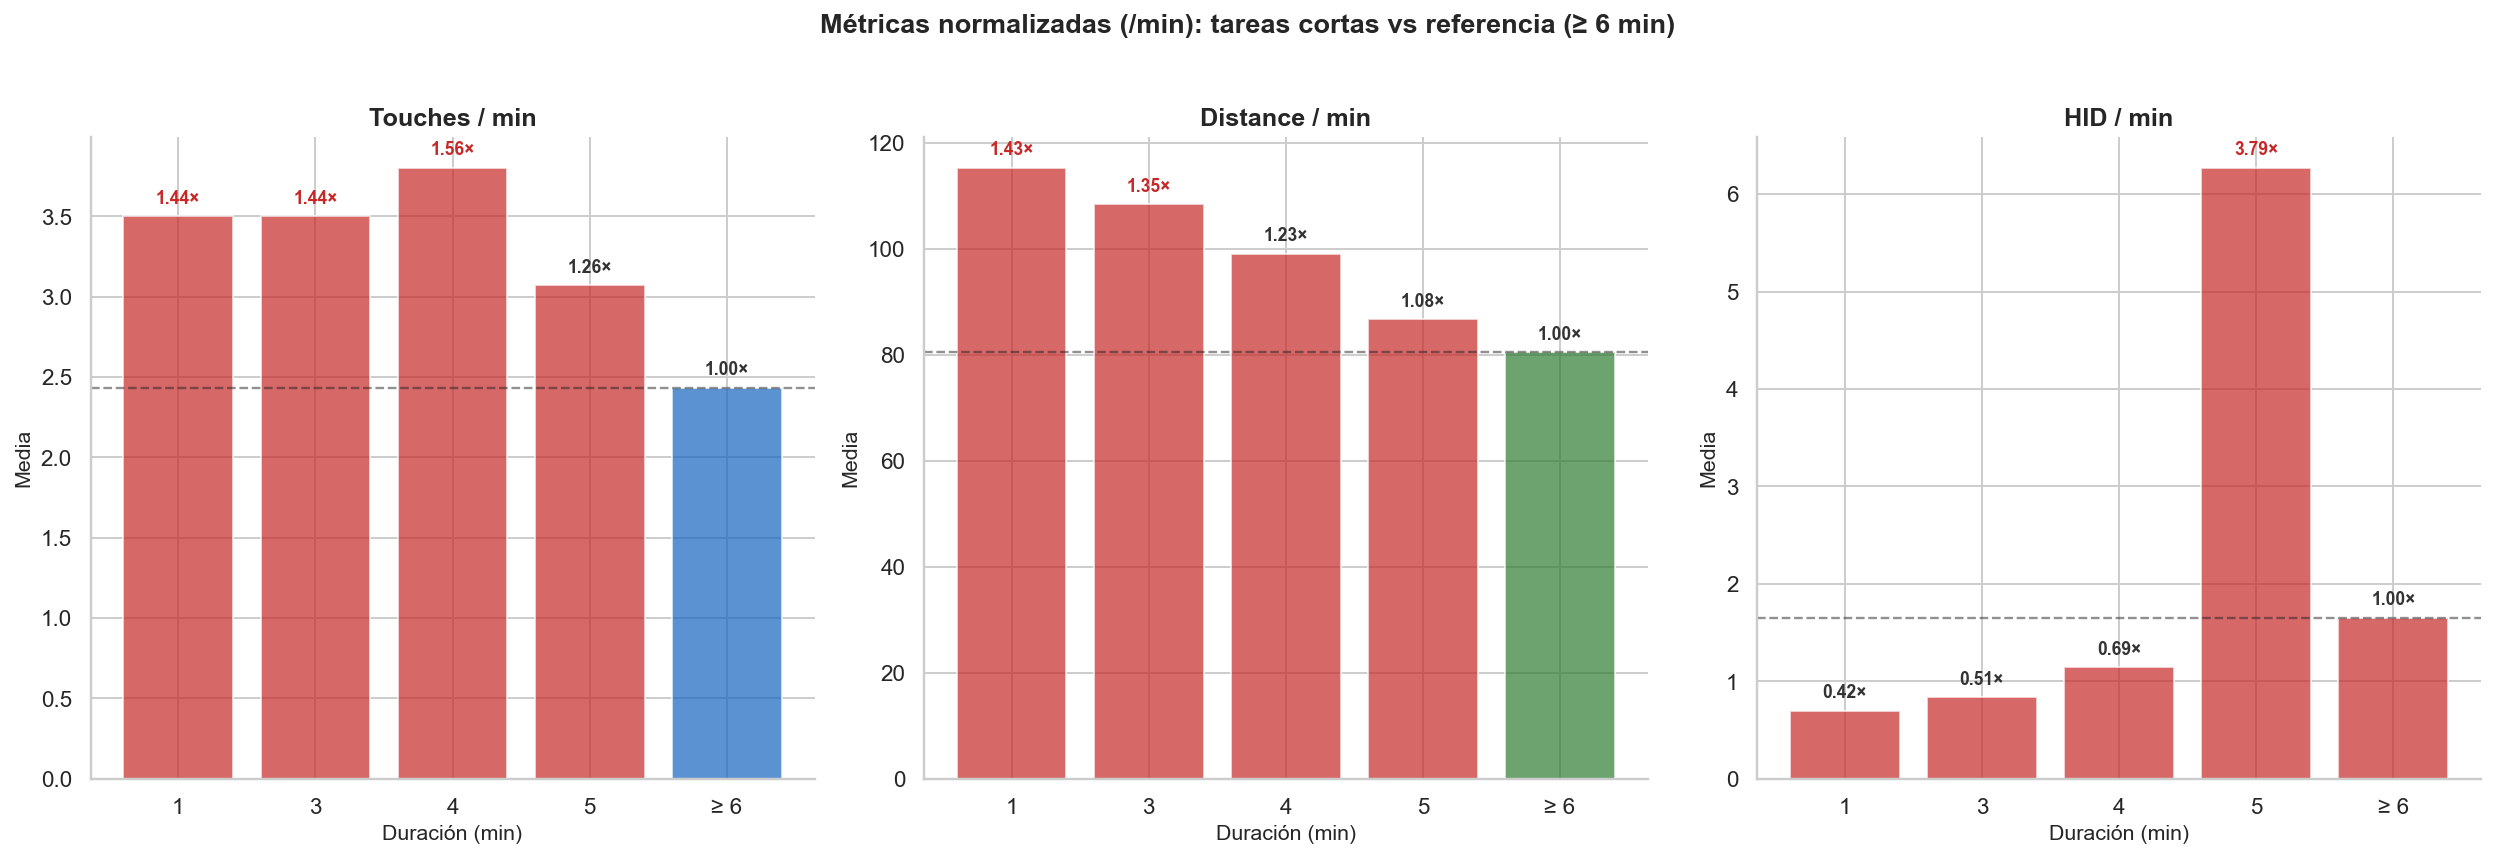

In [68]:
# ── 8.2 Visualización — Métricas /min infladas en tareas cortas ──

col_dur = "Phase Duration (min)"
mask_short = df_clean[col_dur] < 6
ref = df_clean[~mask_short]
duraciones_cortas = sorted(df_clean.loc[mask_short, col_dur].unique().astype(int))

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
metricas = [COL["TouchesPerMin"], COL["DistPerMin"], COL["HIDPerMin"]]
nombres_met = ["Touches / min", "Distance / min", "HID / min"]
colores_met = [PALETTE["azul"], PALETTE["verde"], PALETTE["rojo"]]
media_ref = {m: ref[m].mean() for m in metricas}

for ax, met, nom, clr in zip(axes, metricas, nombres_met, colores_met):
    medias, labels = [], []
    for dur in duraciones_cortas:
        medias.append(df_clean.loc[df_clean[col_dur] == dur, met].mean())
        labels.append(f"{dur}")
    medias.append(media_ref[met])
    labels.append("≥ 6")

    colors_bar = [PALETTE["rojo"]] * len(duraciones_cortas) + [clr]
    ax.bar(labels, medias, color=colors_bar, alpha=0.7, edgecolor="white")
    ax.axhline(media_ref[met], color="#222", ls="--", lw=1.2, alpha=0.5)

    for i, m in enumerate(medias):
        ratio = m / media_ref[met] if media_ref[met] != 0 else 0
        ax.text(i, m + ax.get_ylim()[1] * 0.02, f"{ratio:.2f}×",
                ha="center", fontsize=9, fontweight="bold",
                color=PALETTE["rojo"] if ratio > 1.3 else "#333")

    ax.set_title(nom, fontsize=13, fontweight="bold")
    ax.set_ylabel("Media")
    ax.set_xlabel("Duración (min)")
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("Métricas normalizadas (/min): tareas cortas vs referencia (≥ 6 min)",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

In [69]:
# ── 8.3 Aplicación del filtro de duración ──

UMBRAL_DUR = 6  # minutos
mask_dur_short = df_clean["Phase Duration (min)"] < UMBRAL_DUR
n_elim_dur = mask_dur_short.sum()

df_antes_dur = df_clean.copy()
df_clean = df_clean[~mask_dur_short].reset_index(drop=True)

print("═" * 65)
print(f"  APLICACIÓN DEL FILTRO — Phase Duration < {UMBRAL_DUR} min")
print("═" * 65)
print(f"  Instancias antes (post-criterio 1):   {len(df_antes_dur):,}")
print(f"  Instancias eliminadas (criterio 2):   {n_elim_dur:>5}  ({n_elim_dur/len(df_antes_dur)*100:.2f}%)")
print(f"  Instancias después:                   {len(df_clean):,}")
print("═" * 65)

# ── Tabla comparativa antes/después (criterio 2) ──
print("\n📊 Comparación antes/después del filtro de duración:\n")
comparacion_dur = summarize_before_after(df_antes_dur, df_clean, VD_ALL,
                                          label_antes="Pre-filtro dur",
                                          label_despues="Post-filtro dur")
display(comparacion_dur)

# ── Resumen pipeline completo ──
n_total_elim = len(df) - len(df_clean)
print(f"\n{'═' * 65}")
print(f"  📊 PIPELINE COMPLETO DE LIMPIEZA")
print(f"{'═' * 65}")
print(f"  Entrada original (Matriz_V2):           {len(df):,}")
print(f"  — Criterio 1 (toques p05 conjunto):    −{len(df) - len(df_antes_dur)} ({(len(df) - len(df_antes_dur))/len(df)*100:.2f}%)")
print(f"  — Criterio 2 (duración < {UMBRAL_DUR} min):      −{n_elim_dur} ({n_elim_dur/len(df)*100:.2f}%)")
print(f"  ════════════════════════════════════════════")
print(f"  Salida final:                            {len(df_clean):,}  ({len(df_clean)/len(df)*100:.1f}% conservado)")
print(f"  Total eliminado:                         {n_total_elim} ({n_total_elim/len(df)*100:.2f}%)")
print(f"{'═' * 65}")

═════════════════════════════════════════════════════════════════
  APLICACIÓN DEL FILTRO — Phase Duration < 6 min
═════════════════════════════════════════════════════════════════
  Instancias antes (post-criterio 1):   3,294
  Instancias eliminadas (criterio 2):     115  (3.49%)
  Instancias después:                   3,179
═════════════════════════════════════════════════════════════════

📊 Comparación antes/después del filtro de duración:



N    Media  \
Variable                                Fase                             
Total Touches (#)                       Pre-filtro dur   3294    36.41   
                                        Post-filtro dur  3179    37.30   
Golpeos +15 m/s                         Pre-filtro dur   3294     2.42   
                                        Post-filtro dur  3179     2.49   
Distance Covered (m)                    Pre-filtro dur   3294  1292.72   
                                        Post-filtro dur  3179  1327.11   
High Intensity Distance (20 km/h)       Pre-filtro dur   3294    29.56   
                                        Post-filtro dur  3179    30.29   
Total Touches / min                     Pre-filtro dur   3294     2.47   
                                        Post-filtro dur  3179     2.43   
Golpeos +15 m/s / min                   Pre-filtro dur   3294     0.15   
                                        Post-filtro dur  3179     0.15   
Distance Covered (m) / min              Pre-filtro dur   3294    81.22   
                                        Post-filtro dur  3179    80.44   
High Intensity Distance (20 km/h) / min Pre-filtro dur   3294     1.67   
                                        Post-filtro dur  3179     1.65   

                                                             SD  CV (%)  
Variable                                Fase                             
Total Touches (#)                       Pre-filtro dur    24.61   67.59  
                                        Post-filtro dur   24.53   65.76  
Golpeos +15 m/s                         Pre-filtro dur     2.87  118.20  
                                        Post-filtro dur    2.89  116.04  
Distance Covered (m)                    Pre-filtro dur   736.04   56.94  
                                        Post-filtro dur  725.79   54.69  
High Intensity Distance (20 km/h)       Pre-filtro dur    50.14  169.60  
                                        Post-filtro dur   50.76  167.61  
Total Touches / min                     Pre-filtro dur     1.67   67.78  
                                        Post-filtro dur    1.65   67.75  
Golpeos +15 m/s / min                   Pre-filtro dur     0.19  120.60  
                                        Post-filtro dur    0.17  112.59  
Distance Covered (m) / min              Pre-filtro dur    28.15   34.66  
                                        Post-filtro dur   27.71   34.45  
High Intensity Distance (20 km/h) / min Pre-filtro dur     2.50  149.37  
                                        Post-filtro dur    2.43  147.03


═════════════════════════════════════════════════════════════════
  📊 PIPELINE COMPLETO DE LIMPIEZA
═════════════════════════════════════════════════════════════════
  Entrada original (Matriz_V2):           3,426
  — Criterio 1 (toques p05 conjunto):    −132 (3.85%)
  — Criterio 2 (duración < 6 min):      −115 (3.36%)
  ════════════════════════════════════════════
  Salida final:                            3,179  (92.8% conservado)
  Total eliminado:                         247 (7.21%)
═════════════════════════════════════════════════════════════════


## 9 · Exportación y resumen final

In [70]:
# ── 8.1 Exportación a Matriz_V3.xlsx ──
ruta_salida = "../Datos/Matriz_V3.xlsx"
df_clean.to_excel(ruta_salida, index=False)

print(f"✅ Dataset limpio exportado → {ruta_salida}")
print(f"   {df_clean.shape[0]:,} filas × {df_clean.shape[1]} columnas")

✅ Dataset limpio exportado → ../Datos/Matriz_V3.xlsx
   3,179 filas × 18 columnas


---

## Justificación metodológica

### Criterios aplicados

Se aplicaron **dos criterios de exclusión** de forma secuencial sobre el dataset de entrada (N = 3 426):

---

#### Criterio 1 — No participación por toques (p05 conjunto)

Se excluyeron instancias que presentaban **simultáneamente** valores por debajo del percentil 5 en **Total Touches (#)** y **Total Touches / min**.

**Desglose**:

- Instancias bajo p05 en Total Touches solamente → no se eliminan (puede ser tarea corta con buen ritmo).
- Instancias bajo p05 en Touches/min solamente → no se eliminan (puede ser tarea larga con bajo ritmo pero participación real).
- Instancias bajo p05 en **AMBAS** → se eliminan (participación mínima absoluta y relativa).

**¿Por qué este criterio?**

1. **Conservador y reproducible**: percentiles dinámicos. La conjunción (AND) minimiza falsos positivos.
2. **Basado en la dimensión técnica**: la participación en fútbol se manifiesta a través del contacto con el balón.
3. **Coherencia con Distance Covered**: los eliminados concentran valores muy bajos de distancia (ratio << 1).

---

#### Criterio 2 — Exclusión por duración insuficiente (< 6 min)

Se excluyeron instancias con **Phase Duration < 6 min**, basándose en tres argumentos:

1. **Representatividad del constructo**: tareas de 1-5 min no alcanzan la duración mínima para que la tarea sea realmente representativa. Los indicadores técnicos y físicos no reflejan la dinámica real de un SSG/LSG, únicamente de ciclos y subfases del juego demasiado cortas como para que sean reales. No son lo suficientemente relevantes como para condicionar el estudio posterior a través del GLMM, en el cual podrían aparecer sesgos provenientes de estas instancias. 

2. **Artefacto estadístico por normalización /min**: denominadores pequeños (1-5 min) amplifican el ruido de medición. Por ejemplo, Touches/min muestra ratios de hasta **1.56×** y HID/min de hasta **3.79×** respecto al resto del dataset. Estas métricas infladas distorsionarían los modelos GLMM.

3. **Integridad del diseño factorial 2³**: **todas** las instancias < 6 min pertenecen exclusivamente al grupo SSG y a solo 3 de los 12 equipos del estudio (8 de 191 Phase Ids). Incluirlas sesgaría diferencialmente las estimaciones del efecto del formato de juego en los modelos.

---

### Principios generales

1. **No se eliminan outliers superiores**: representan rendimiento extremo legítimo, fundamental para ANOVA, GLMM e ICC.
2. **Variables no usadas como criterio de exclusión**:
   - **Golpeos +15 m/s**: alta proporción natural de ceros. No indica no participación.
   - **High Intensity Distance (20 km/h)**: ceros legítimos en tareas sin sprints (> 5.5 m/s ≈ 20 km/h). No indica no participación.

### Compatibilidad con análisis posteriores

- **ANOVA / modelos lineales**: reduce ruido, mejora estimación de efectos fijos.
- **GLMM**: mantiene la estructura jerárquica (jugador dentro de sesión/fase). Los efectos fijos del modelo son `Formato_del_Juego`, `Polaridad`, `Equilibrio` y sus interacciones.
- **ICC**: preserva variabilidad inter-sujeto al eliminar registros espurios.

### Resumen numérico del pipeline

| Fase | N instancias | Δ |
|:---|:---:|:---:|
| Entrada (Matriz_V2.xlsx) | 3 426 | — |
| Criterio 1: p05 conjunto (toques) | 3 294 | −132 (3.85 %) |
| Criterio 2: duración < 6 min | 3 179 | −115 (3.49 %) |
| **Salida (Matriz_V3.xlsx)** | **3 179** | **−247 (7.21 %)** |
| Dimensiones finales | 3 179 × 18 | — |